# Implement folder Planck equation


In [1]:
import numpy as np
import torch
from scipy.integrate import solve_bvp
import matplotlib.pyplot as plt
import os, warnings
import numpy as np
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")
import numpy as np
import pandas as pd

In [2]:

mu_M=-0.79
sigma_M=1.68
# sigma_M=1.75

S_mat=None                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}





mu=0.001*3*40
p_sil=0.5*(mu)+(1-mu)
p_let=0.3*(mu)
p_aa=0.2*(mu)
E_a=np.log(40)                       
kBT=1                       # thermal factor
N_i=2500  
N_max=2500 
mu_i=0.0 
sigma_i=0.001*np.sqrt(40)
p_diff=0.10
c=170# 800, 1120, 920, 510


    # ---------------- mutation statistics -------------------------------
f_aa  = p_aa / (p_aa + p_sil)
f_sil = 1.0 - f_aa
v_adv = f_aa * mu_M
D     = f_aa * (sigma_M**2 + f_sil * mu_M**2)
lam = np.log(2.0) + np.log1p(-p_let) + np.log1p(-p_diff)

In [3]:


# ---------------------------------------------------------------------
# 1.  Run FP simulation  +  build Γ & ∇Γ lists
# ---------------------------------------------------------------------
def fp_density_time_series_kD(
    # biological / model parameters ---------------------------------------

    get_C=lambda t, v: 5.0,          # user-supplied concentration C_v(t)
    S_mat=None,                      # shape (N_h, n_A) : s_{k,v} ∈ {±1}
    N_i=N_i,  N_max=N_max,
    # grid / time ----------------------------------------------------------
    h_min=-1.0, h_max=20.0, d_h=0.05,
    T=30.0,  dt=0.001,
    # output ---------------------------------------------------------------
    snapshot_interval=0.005,
    verbose=False,
    rho_c=0.
):
    """
    Simulate k-dimensional GC Fokker–Planck dynamics in h-space.

    Parameters
    ----------
    S_mat : ndarray (N_h, n_A)
        Binary motif matrix: each column = antigen, each row = shape component.
    get_C : callable (t, v) → C_v(t)
        Returns surface concentration of antigen v at time t.
    """
    # ---------------- basic checks --------------------------------------
    if S_mat is None:
        raise ValueError("S_mat (binary motif matrix) must be provided")
    N_h, n_A = S_mat.shape          # k = dimension of h



    if D > 0.0:
        dt_max = d_h**2 / (2.0 * N_h * D)
        if dt > dt_max:
            raise ValueError(f"dt = {dt:.3g} exceeds CFL limit {dt_max:.3g}")


    # ---------------- k-dim Cartesian grid ------------------------------
    h_axis = np.arange(h_min, h_max + d_h, d_h)
    h_axes = (h_axis,) * N_h
    h_mesh = np.meshgrid(*h_axes, indexing="ij")      # list of length k
    dH     = d_h**N_h

    # ---------------- Gaussian initial population -----------------------
    g1d = np.exp(-(h_axis - mu_i) ** 2 / (2.0 * sigma_i**2))
    rho = np.prod(np.meshgrid(*([g1d] * N_h), indexing="ij"), axis=0)
    rho *= N_i / (rho.sum() * dH)

    snapshots = [rho.copy()]
    times     = [0.0]

    # ---------------- pre-allocate helper arrays ------------------------
    E_stack = np.zeros((n_A,) + rho.shape)           # energies  E_v(h)

    n_steps    = int(round(T / dt))
    snap_every = max(1, int(round(snapshot_interval / dt)))
    omegas=[0]
    # -------------------------------------------------------------------
    for step in range(1, n_steps + 1):
        t_now = step * dt
        N_pop = rho.sum() * dH

        # --- time-dependent concentrations -----------------------------
        C_vec  = np.array([get_C(t_now, v) for v in range(n_A)], dtype=float)
        C_tot  = C_vec.sum()

        # If no antigen is present, skip selection (pure drift/diffusion)
        if C_tot == 0.0:
            if verbose and step % snap_every == 0:
                print(f"{step:5d}  t={t_now:6.2f}  (no antigen present)")
            if step % snap_every == 0:
                snapshots.append(rho.copy());  times.append(t_now)
            continue

        # --- binding energies  E_v(h) ----------------------------------
        # S_mat.T : (n_A, N_h);  stacked h_mesh : (N_h, …grid…)
        E_stack = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        #            → shape (n_A, …grid…)

        # Broadcast C_v to all grid points
        C_broad = C_vec.reshape((n_A,) + (1,) * N_h)

        # --- antigen internalisation gate  P_Ag ------------------------
        exp_term  = np.exp((E_stack - E_a) / kBT)
        numer_PAg = (C_broad * exp_term).sum(axis=0)
        P_Ag      = numer_PAg / (1.0 + numer_PAg)

        # --- T‐cell help gate  P_T  (concentration-weighted) ----------
        eE   = np.exp(E_stack / kBT)
        Phi  =  eE.sum(axis=0)                 # Σ_v C_v e^{E_v/kBT}
        Phi_bar = (rho * Phi).sum() * dH / N_pop
        P_T  = Phi / (Phi + Phi_bar / C_tot)

        # --- growth/decay rate Γ(h,t) ----------------------------------
        log_sel = np.log(P_Ag) + np.log(P_T)
        avg_log = (rho * log_sel).sum() * dH / N_pop
        Omega   = 0.0 if N_pop < N_max+0.1 else max(0.0, lam + avg_log)
        Gamma   = lam + log_sel - Omega

        # --- conservative flux divergence ------------------------------
        div_total = np.zeros_like(rho)
        for ax in range(N_h):
            rho_fwd  = np.roll(rho, -1, axis=ax)

            adv_flux  = v_adv * (rho if v_adv >= 0 else rho_fwd)
            diff_flux = -0.5 * D * (rho_fwd - rho) / d_h
            J_int     = adv_flux + diff_flux            # at cell interfaces

            # trim last cell (fwd neighbour outside domain)
            slc = [slice(None)] * N_h;  slc[ax] = slice(0, -1)
            J_int = J_int[tuple(slc)]

            # build full flux array with zero at boundaries
            J_shape = list(rho.shape); J_shape[ax] += 1
            J = np.zeros(J_shape)
            idx = [slice(None)] * N_h;  idx[ax] = slice(1, -1)
            J[tuple(idx)] = J_int

            div_total += np.diff(J, axis=ax) / d_h

        # --- explicit Euler update -------------------------------------
        rho += dt * (Gamma * rho - div_total)
        # rho[rho < 0.001] = 0

        np.maximum(rho, 0.0, out=rho)                    # clip negatives
        cell_density = 1.0 / dH
        rho[rho < rho_c * cell_density] = 0.0
        
        np.maximum(rho, 0.0, out=rho)                    # clip negatives
        # --- book-keeping ----------------------------------------------
        if step % snap_every == 0:
            snapshots.append(rho.copy())
            times.append(t_now)
            omegas.append(Omega)

        if verbose and step % snap_every == 0:
            mean_Gamma = (rho * Gamma).sum() * dH / N_pop
            mean_h = [(rho * h_mesh[ax]).sum() * dH / N_pop for ax in range(N_h)]
            mean_h_str = "  ".join(f"⟨h_{i+1}⟩={m:6.2f}" for i, m in enumerate(mean_h))
            print(f"{step:5d}  t={t_now:6.2f}  N={N_pop:8.1f}  Ω={Omega:7.3f}  "
                  f"⟨Γ⟩={mean_Gamma:8.3f}  {mean_h_str}")

    return h_axes, np.array(times), np.stack(snapshots), np.array(omegas)



In [4]:
def run_fp(S_mat, get_C, *, T=20.0, verbose=False, rho_c=0.):
    """
    Returns a dict 'fp_ctx' with everything downstream functions need.
    """
    axes, times, rho_t, omegas = fp_density_time_series_kD(
        S_mat=S_mat, get_C=get_C, T=T, verbose=verbose, rho_c=rho_c
    )

    # ---------- Φ̄(t_k) --------------------------------------------
    N_h, n_A  = S_mat.shape
    d_h       = axes[0][1] - axes[0][0]
    dH        = d_h**N_h
    h_mesh    = np.meshgrid(*axes, indexing="ij")
    E_full    = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))

    Phi_bar = np.zeros_like(times, dtype=float)
    for k, t_now in enumerate(times):
        C_vec = np.array([get_C(float(t_now), v) for v in range(n_A)])
        Phi   = ( np.exp(E_full/kBT)).sum(axis=0)
        rho   = rho_t[k]
        Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)

    # ---------- Γ & ∇Γ snapshots (autograd) ------------------------
    S_torch = torch.tensor(S_mat, dtype=torch.float64)
    gamma_list, grad_list = [], []

    for k, t_now in enumerate(times):
        Phi_b  = float(Phi_bar[k])
     
        omega  = float(omegas[k])
        C_vec  = np.array([get_C(float(t_now), v) for v in range(n_A)], dtype=float)
        C_t    = torch.tensor(C_vec, dtype=torch.float64)

        def γ(h_t, C_t=C_t, Phi_b=Phi_b, omega=omega):
            E_v  = torch.mv(S_torch.T, h_t)
            P_Ag = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
            P_Ag = P_Ag / (1.0 + P_Ag)
            Phi  = torch.exp(E_v / kBT).sum()
            P_T  = Phi / (Phi + Phi_b / C_t.sum())
            return lam + torch.log(P_Ag) + torch.log(P_T) - omega

        def gγ_np(h_np, γ=γ):          # capture γ itself
            h_t = torch.tensor(h_np, requires_grad=True, dtype=torch.float64)
            γ(h_t).backward()
            return h_t.grad.numpy()

        gamma_list.append(γ)
        grad_list.append(gγ_np)

    return dict(
        axes=axes, times=times, rho_t=rho_t, omegas=omegas,
        Phi_bar=Phi_bar,
        gamma_list=gamma_list, grad_list=grad_list,
        S_mat=S_mat, get_C=get_C
    )



In [5]:
import numpy as np
import matplotlib.pyplot as plt

def plot_fp_density_time_dim(fp_ctx, dim=0, *,
                             disp_step=5, cmap="Greys",
                             sol=None, vmax_fixed=2000.0):
    """
    Heat-map of ρ(t, h_dim) with a white background and shades of black.
    The color scale is fixed between 0 and 2500.
    """
    # Force default light style
    plt.style.use('default')
    
    axes, times, rho_t = fp_ctx["axes"], fp_ctx["times"], fp_ctx["rho_t"]
    N_h = len(axes)
    if not (0 <= dim < N_h):
        raise ValueError(f"dim must be in [0,{N_h-1}]")

    h_axis = axes[dim]

    # --- marginal over all dims except `dim` --------------------------
    marginal_axes = tuple(i + 1 for i in range(N_h) if i != dim)
    
    if N_h > 1:
        steps = [(axes[i][1] - axes[i][0]) for i in range(N_h) if i != dim]
        dH = np.prod(steps)
    else:
        dH = 1.0
        
    rho_marg = rho_t.sum(axis=marginal_axes) * dH
    rho_marg[np.isnan(rho_marg)] = 0

    # --- plot settings ------------------------------------------------
    plt.rcParams.update({
        "font.size": 9,
        "axes.labelsize": 9,
        "axes.titlesize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
        "figure.figsize": (3.4, 2.6),
        "figure.dpi": 300,
        "font.family": "serif",
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
    })

    fig, ax = plt.subplots(facecolor='white')

    # 3. Plot Heatmap 
    # vmin=0 and vmax=vmax_fixed (2500) ensures the scale is locked
    im = ax.imshow(rho_marg.T, 
                    origin="lower", 
                    aspect="auto",
                    extent=[times[0], times[-1], h_axis[0], h_axis[-1]],
                    cmap=cmap, 
                    vmin=0.0, 
                    vmax=vmax_fixed)

    # 4. Add Colorbar with fixed range
    # Ticks are set at 0, 625, 1250, 1875, 2500
    cbar_ticks = np.linspace(0.0, vmax_fixed, 5)
    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, ticks=cbar_ticks)
    cbar.set_label(r"$\rho(t,\epsilon)$", fontsize=9)
    cbar.ax.tick_params(labelsize=8)
    
    # 5. Labels and Ticks
    ax.set_xlabel(r"GC rounds (12h)")
    ax.set_ylabel(r"Affinity $\epsilon$")
    ax.set_xticks(np.arange(times[0], times[-1] + 1e-9, disp_step))
    
    ax.tick_params(direction="in", top=True, right=True, colors='black')
    for spine in ax.spines.values():
        spine.set_edgecolor('black')
        spine.set_visible(True)

    # 6. Overlay Trajectory
    if sol is not None:
        ax.plot(sol.x, sol.y[dim], 
                color='#D0021B', 
                lw=1.2, 
                linestyle='--', 
                label=r"Least-action")
        
        legend = ax.legend(frameon=True, loc='upper right', fontsize=7)
        legend.get_frame().set_facecolor('white')
        legend.get_frame().set_edgecolor('black')

    plt.tight_layout(pad=0.2)
    plt.show()

# Result for different c values

In [6]:
c_array = [ 10, 50, 100, 170, 500]
for c in c_array: 
    fp_ctx = run_fp(
            S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
            get_C=lambda t, v: c,
            T=140,
            verbose=False
        )
    # 1. Extract relevant data for the last time step
    rho_last = fp_ctx['rho_t'][-1]
    axes = fp_ctx['axes']
    S_mat = fp_ctx['S_mat']

    # 2. Reconstruct the grid and calculate the volume element (dH)
    d_h = axes[0][1] - axes[0][0]
    dH = d_h ** len(axes)
    h_mesh = np.meshgrid(*axes, indexing="ij")

    # 3. Calculate affinity (epsilon) for the first antigen (v=0) across the entire grid
    # E_full shape: (n_A, N_h1, N_h2, ...)
    E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
    epsilon = E_full[0].flatten()

    # Convert density to probability mass for accurate binning
    rho_mass_flat = rho_last.flatten() * dH 
    print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is OK

    #save
    df=pd.DataFrame({
        'epsilon': epsilon,
        'rho_epsilon': rho_mass_flat
    })
    
    df.to_csv('rho_epsilon_last_step_c='+str(c)+'.csv')


total mass check (should be close to N_i): 2500.7003167068283
total mass check (should be close to N_i): 2500.390702044684
total mass check (should be close to N_i): 2500.5117502826474


KeyboardInterrupt: 

# Probability of survival

In [ ]:

c_array = np.logspace(-1, 2, 6)  # 10 values from 1 to 1000 on a log scale
rho_c_array = [0, 1e-7, 1e-5]
results = {}
for rho_c in rho_c_array:
    for c in c_array: 
        fp_ctx = run_fp(
                S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
                get_C=lambda t, v: c,
            T=140,
            verbose=False,
            rho_c=rho_c
        )
        # 1. Extract relevant data for the last time step
        rho_last = fp_ctx['rho_t'][-1]
        axes = fp_ctx['axes']
        S_mat = fp_ctx['S_mat']

        # 2. Reconstruct the grid and calculate the volume element (dH)
        d_h = axes[0][1] - axes[0][0]
        dH = d_h ** len(axes)
        h_mesh = np.meshgrid(*axes, indexing="ij")

        # 3. Calculate affinity (epsilon) for the first antigen (v=0) across the entire grid
        # E_full shape: (n_A, N_h1, N_h2, ...)
        E_full = np.tensordot(S_mat.T, np.stack(h_mesh, axis=0), axes=(1, 0))
        epsilon = E_full[0].flatten()

        # Convert density to probability mass for accurate binning
        rho_mass_flat = rho_last.flatten() * dH 
        print('total mass check (should be close to N_i):', rho_mass_flat.sum())#is 
        #if nan: preplace with 0
        total_pop=rho_mass_flat.sum()
        if np.isnan(total_pop):
            print('NaN detected in total population. Replacing with 0.')
            total_pop = 0.0

        #save total pop
        results[(c, rho_c)] = total_pop


    

total mass check (should be close to N_i): 7.43032139270172e-133
total mass check (should be close to N_i): 4.099514019667539e-60
total mass check (should be close to N_i): 1.0887791863844071e-10
total mass check (should be close to N_i): 2500.2186967438347
total mass check (should be close to N_i): 2500.5625204468442
total mass check (should be close to N_i): 2500.5117502826474


C:\Users\maria\AppData\Local\Temp\ipykernel_34328\3051279314.py:94: RuntimeWarning: invalid value encountered in scalar divide
  Phi_bar = (rho * Phi).sum() * dH / N_pop


total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.


C:\Users\maria\AppData\Local\Temp\ipykernel_34328\2491409311.py:21: RuntimeWarning: invalid value encountered in scalar divide
  Phi_bar[k] = (rho * Phi).sum()*dH / (rho.sum()*dH)


total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.
total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.
total mass check (should be close to N_i): 2500.3038853854346
total mass check (should be close to N_i): 2500.5991290711363
total mass check (should be close to N_i): 2500.502310734782
total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.
total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.
total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.
total mass check (should be close to N_i): nan
NaN detected in total population. Replacing with 0.
total mass check (should be close to N_i): 2500.599104739784
total mass check (should be close to N_i): 2500.6711182051804


In [ ]:
import matplotlib.pyplot as plt
#save as csv
df_survival = pd.DataFrame([
    {'c': c, 'rho_c': rho_c, 'survival_rate': results[(c, rho_c)] / N_i}
    for rho_c in rho_c_array for c in c_array
])

df_survival.to_csv('survival_rate_fp_log.csv', index=False)


# Least actions

In [7]:
def make_grad_Gamma(fp_ctx):
    times, grads = fp_ctx["times"], fp_ctx["grad_list"]
    def grad(h, t):
        if t <= times[0]:  return grads[0](h)
        if t >= times[-1]: return grads[-1](h)
        hi = np.searchsorted(times, t)
        lo = hi - 1
        w  = (t-times[lo])/(times[hi]-times[lo])
        return (1.-w)*grads[lo](h) + w*grads[hi](h)
    return grad
from scipy.integrate import solve_bvp

def solve_optimal_trajectory(
        hf, fp_ctx, *, mesh=1000, max_nodes=20_000, plot=False):
    """
    Computes the least-action trajectory from h(t0)=0 to h(tf)=hf.
    Works for arbitrary dimensionality N = fp_ctx["S_mat"].shape[0].
    """
    # ---------------- basic info ----------------
    times   = fp_ctx["times"]
    grad_G  = make_grad_Gamma(fp_ctx)
    t0, tf  = times[0], times[-1]
    N       = fp_ctx["S_mat"].shape[0]          # number of h coordinates

    # ------------- final boundary vector -------------
    if np.isscalar(hf):
        hf = np.repeat(float(hf), N)            # same target for every dim
    else:
        hf = np.asarray(hf, dtype=float)
        if hf.size != N:
            raise ValueError(
                f"hf must have length {N} (one per shape dim); got {hf.size}")

    # ----------------- ODE system --------------------
    # state y = (h, v)  ⇒  size 2N
    def ode(t, y):
        h, v = y[:N], y[N:]                      # each is shape (N, len(t))
        a    = np.empty_like(h)
        for j, tj in enumerate(t):               # loop over mesh points
            a[:, j] = -D * grad_G(h[:, j], tj)   # acceleration
        return np.vstack((v, a))

    # ------------- boundary conditions --------------
    def bc(ya, yb):
        # ya[:N]  : h(t0)  ;  yb[:N] : h(tf)
        return np.hstack((ya[:N], yb[:N] - hf))

    # ------------- initial mesh & guess -------------
    t_mesh  = np.linspace(t0, tf, mesh)
    y_guess = np.zeros((2 * N, mesh))
    for i in range(N):                           # linear interpolation guess
        y_guess[i] = hf[i] * (t_mesh - t0) / (tf - t0)

    # ------------- solve BVP ------------------------
    sol = solve_bvp(ode, bc, t_mesh, y_guess, max_nodes=max_nodes)
    if not sol.success:
        raise RuntimeError(sol.message)

    # ------------- optional plot --------------------
    if plot:
        plt.figure(figsize=(6, 3))
        for i in range(N):
            plt.plot(sol.x, sol.y[i], label=r"$Affinity $(-E(h))$")
        plt.xlabel("GC rounds (12h)")
        plt.ylabel("shape coordinate")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return sol


def compute_least_action(sol, fp_ctx, *, baseline=True, verbose=False):
    """
    Return S_opt   (and S_lin when baseline=True)
    Compatible with any number N = S_mat.shape[0] of shape coordinates.
    """
    # ------------------------------------------------------------------
    times   = fp_ctx["times"]
    omegas  = fp_ctx["omegas"]
    Phi_bar = fp_ctx["Phi_bar"]
    get_C   = fp_ctx["get_C"]
    S_mat   = fp_ctx["S_mat"]
    n_A     = S_mat.shape[1]
    N       = S_mat.shape[0]               # number of h coordinates

    # constants (assumed already defined in the notebook)
    v_vec   = f_aa * mu_M * np.ones(N)     # deterministic drift term

    # --- torch version of S_mat for Γ --------------------------------
    S_T     = torch.tensor(S_mat, dtype=torch.float64)

    # -------------------- Γ(t, h) ------------------------------------
    def Γ(t, h_np):
        """
        Growth rate minus omega at time t and shape h (numpy array length N).
        Returns a scalar float.
        """
        # match given t to nearest entry in 'times'
        k      = int(np.argmin(np.abs(times - t)))
        omega  = omegas[k]
        Phi_b  = Phi_bar[k]

        C_vec  = np.array([get_C(float(times[k]), v) for v in range(n_A)],
                          dtype=float)

        # torch variables
        h_t = torch.tensor(h_np, dtype=torch.float64)
        C_t = torch.tensor(C_vec, dtype=torch.float64)

        # energy of each antigen
        E_v = torch.mv(S_T.T, h_t)         # shape (n_A,)

        # binding probability to target antigen
        PAg = (C_t * torch.exp((E_v - E_a) / kBT)).sum()
        PAg = PAg / (1.0 + PAg)

        # total binding probability (any antigen)
        Phi = (torch.exp(E_v / kBT)).sum()
        PT  = Phi / (Phi + Phi_b / C_t.sum())

        return (lam + torch.log(PAg) + torch.log(PT) - omega).item()

    # ----------------- extract optimal traj ---------------------------
    t_mesh = sol.x                       # shape (m,)
    h_opt  = sol.y[:N].T                 # shape (m, N)
    v_opt  = sol.y[N:2*N].T              # shape (m, N)

    # ----------------- action functional ------------------------------
    def S_of(h, v):
        g    = np.array([Γ(ti, hi) for ti, hi in zip(t_mesh, h)])
        kin  = np.sum((v - v_vec) ** 2, axis=1) / (2 * D)
        return -np.trapz(g - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)
    if not baseline:
        if verbose:
            print(f"S_opt = {S_opt:.6e}")
        return S_opt

    # ---------------- linear baseline trajectory ----------------------
    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])      # vector length N
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope[None, :]
    v_lin  = np.tile(slope, (len(t_mesh), 1))
    S_lin  = S_of(h_lin, v_lin)

    if verbose:
        print(f"S_opt = {S_opt:.6e}   S_lin = {S_lin:.6e}   ΔS = {S_lin - S_opt:.6e}")

    return S_opt, S_lin


In [8]:
import numpy as np
import copy
print(f"\nRunning FP simulation ")

fp_ctx = run_fp(
        S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
        get_C=lambda t, v: 170.0,
        T=140,
        verbose=False
    )
for t in [3,4,5,6,7,8,9,10]:
  
    fp_ctx_safe = copy.deepcopy(fp_ctx)
    sol = solve_optimal_trajectory([t], fp_ctx_safe)
    print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
    plot_fp_density_time_dim(fp_ctx, sol=sol, disp_step=20)
    S, _ = compute_least_action(sol, fp_ctx, verbose=True)

    np.savetxt(f"trajectory_h_140_{t}.csv", sol.y[0], delimiter=",")
    print("Saved sol.y[0] to trajectory_h.csv")






Running FP simulation 


KeyboardInterrupt: 


Running FP simulation for T=140 seconds


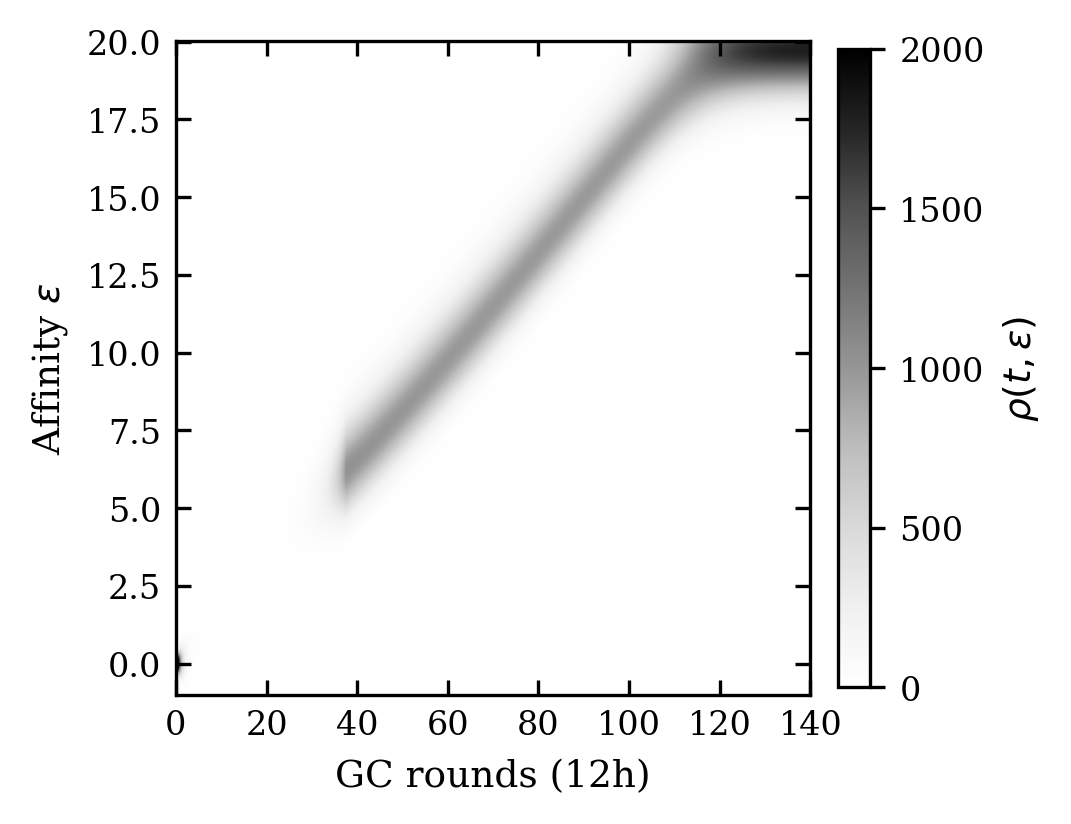


Running FP simulation for T=140 seconds


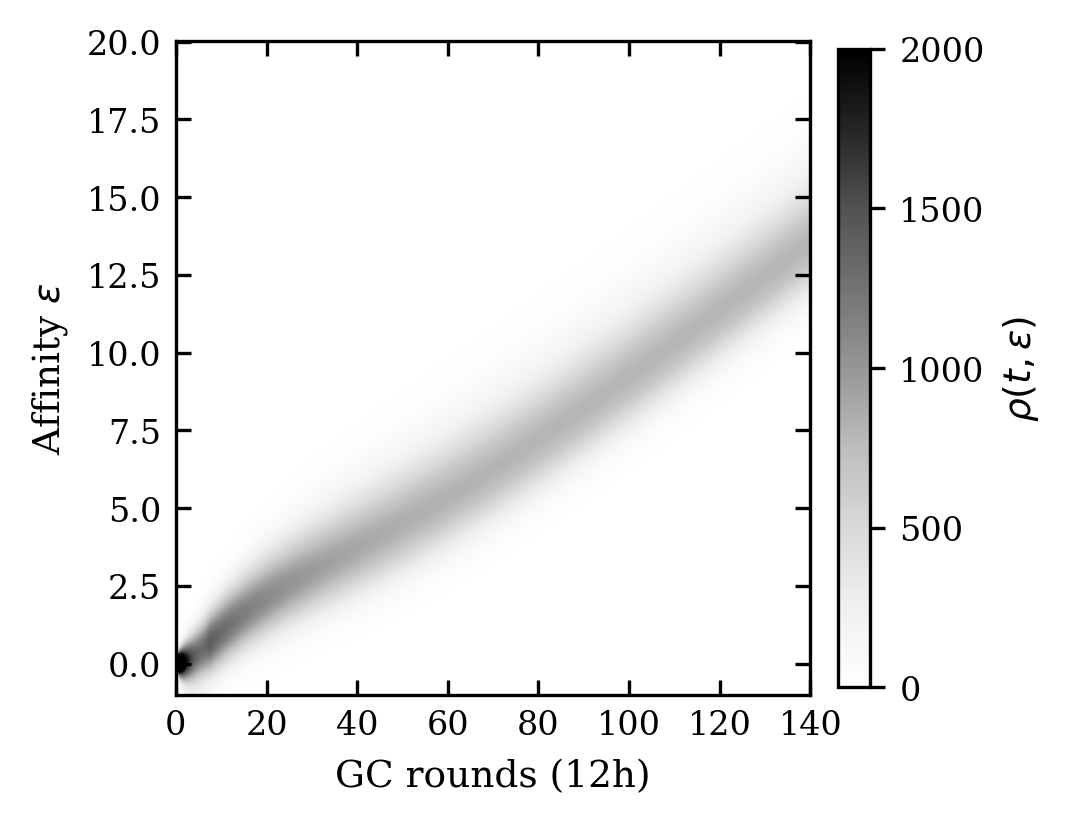


Running FP simulation for T=140 seconds


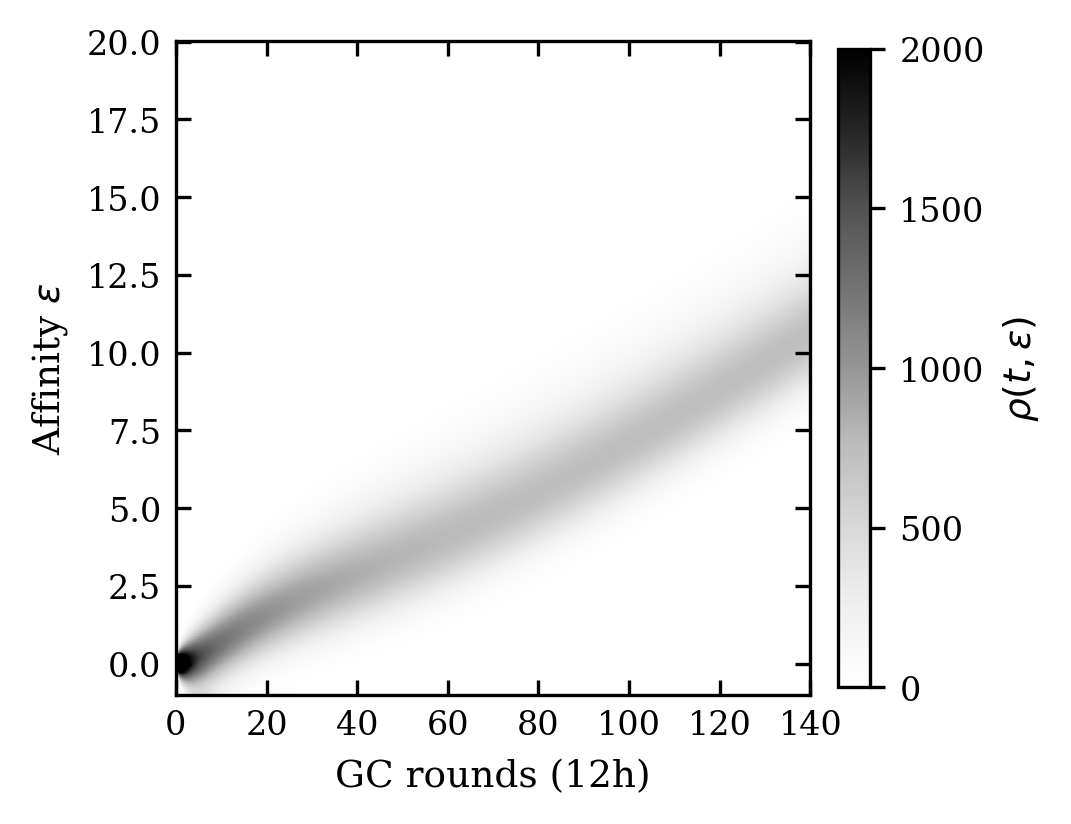


Running FP simulation for T=140 seconds


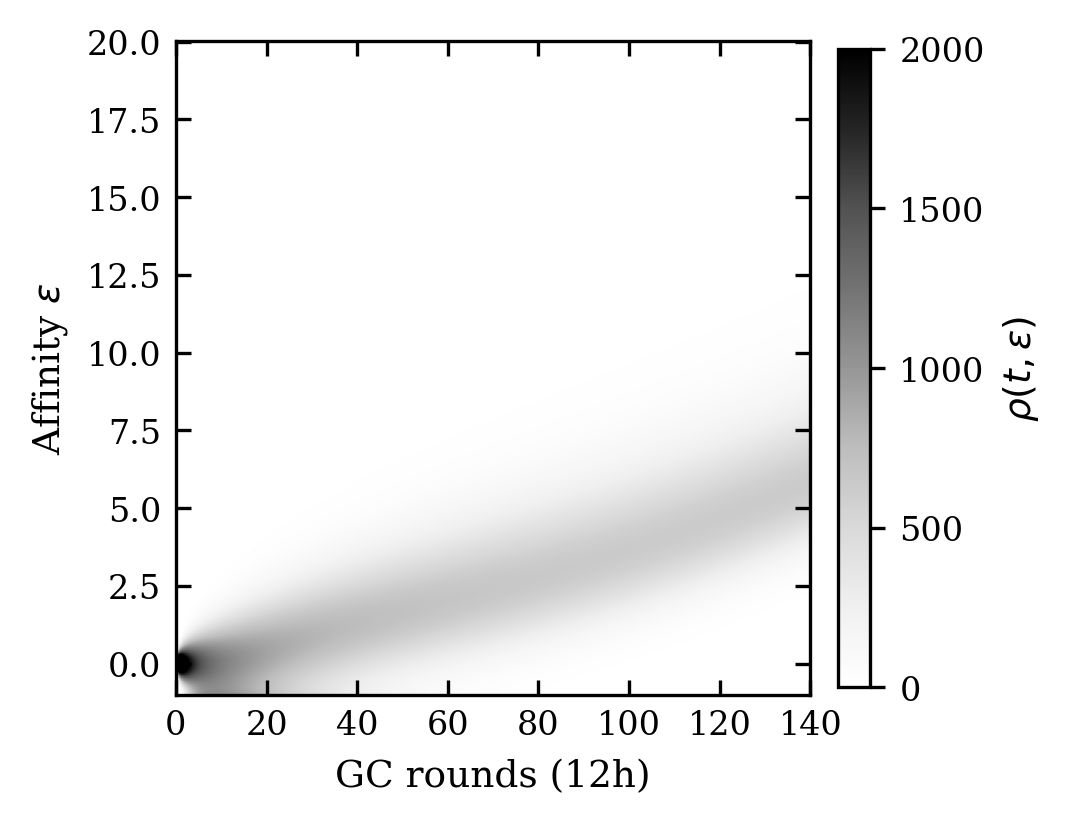

In [ ]:

T=140
for c in [1,10,50,100, 500]:
    print(f"\nRunning FP simulation for T={T} seconds")
    fp_ctx = run_fp(
        S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
        get_C=lambda t, v: c,
        T=T,
        verbose=False
    )
    plot_fp_density_time_dim(fp_ctx, sol=None, disp_step=20)

In [ ]:
c=170

# least action value analysis

In [14]:
import copy, numpy as np, matplotlib.pyplot as plt
from matplotlib import rcParams

# ------------------------------------------------------------------
# 0.  Run FP once  (your run_fp definition must be in scope)
# ------------------------------------------------------------------
fp_ctx = run_fp(
    S_mat=np.array([[1.0]]),
    get_C=lambda t, v: c,
    T=140.0,
    verbose=False
)

h_axis    = fp_ctx["axes"][0]
rho_final = fp_ctx["rho_t"][-1].squeeze()

# ------------------------------------------------------------------
# 1.  Sample 20 starting points in [0, 10]
# ------------------------------------------------------------------
h_min, h_max = 4.0, 14.0
h_samples = np.linspace(h_min, h_max, 10)

log_rho_grid = np.log(rho_final + 1e-12)
log_rho_samp = np.interp(h_samples, h_axis, log_rho_grid)

S_vals = np.empty_like(h_samples)

# ------------------------------------------------------------------
# 2.  Compute least-action values
# ------------------------------------------------------------------
for i, h0 in enumerate(h_samples):
    fp_ctx_i = copy.copy(fp_ctx)
    sol_i    = solve_optimal_trajectory([h0], fp_ctx_i)
    S_i, _   = compute_least_action(sol_i, fp_ctx_i, verbose=False)
    S_vals[i] = S_i




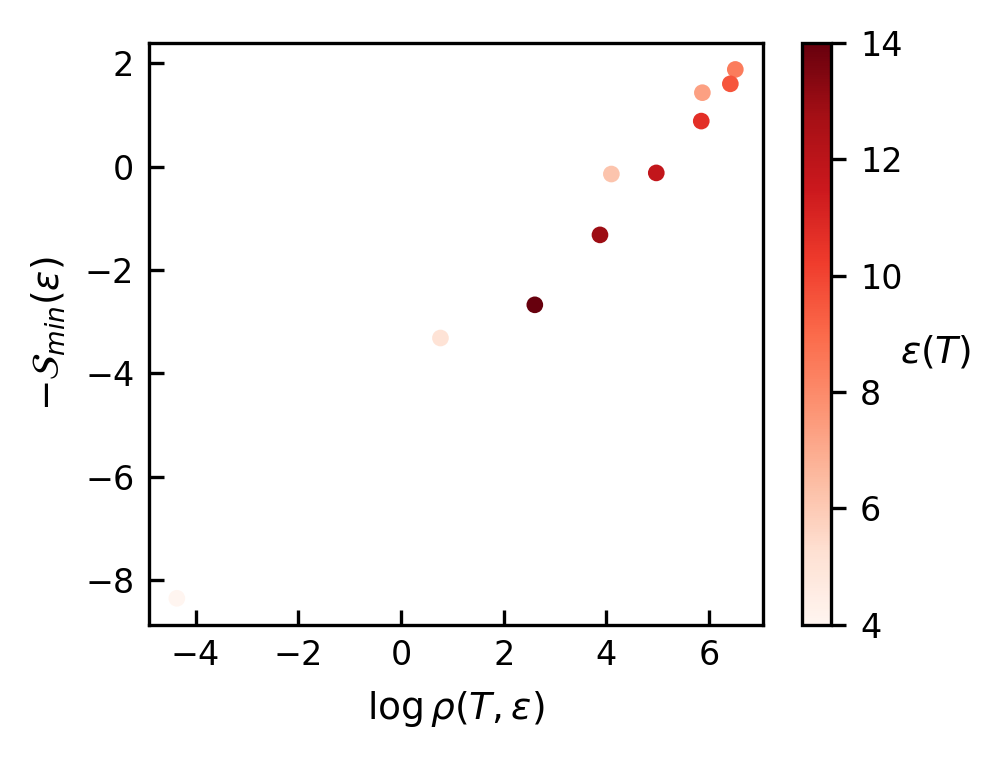

In [15]:
rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),  # ≈8.6 cm × 6.6 cm
    "figure.dpi": 300,
})

fig, ax = plt.subplots()
sc = ax.scatter(log_rho_samp, -S_vals, c=h_samples, cmap="Reds", edgecolors="none")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon(T)$", rotation=0, labelpad=8)

ax.set_xlabel(r"$\log \rho(T,\epsilon)$")
ax.set_ylabel(r"$-\mathcal{S}_{min}(\epsilon)$")
# ax.set_title(r"Least action versus log density")
ax.tick_params(direction="in")
ax.grid(False)

fig.tight_layout()
plt.show()


# Entropic correction

In [16]:
import numpy as np
import torch
import scipy.linalg

def compute_global_hessian_and_det(sol, fp_ctx, verbose=True):
    """
    Constructs the full Block-Tridiagonal Hessian matrix for the Action
    and computes its determinant.
    
    The variable vector is the flattened trajectory: 
    X = [h(t_1), h(t_2), ..., h(t_{m-2})]
    (Excluding fixed endpoints t_0 and t_{m-1} for Dirichlet boundary conditions)
    """
    # ------------------------------------------------------------------
    # 1. Unpack Context & Constants
    # ------------------------------------------------------------------
    times   = fp_ctx["times"]
    omegas  = fp_ctx["omegas"]
    Phi_bar = fp_ctx["Phi_bar"]
    get_C   = fp_ctx["get_C"]
    S_mat   = fp_ctx["S_mat"]
    
    # Physical Constants

    # Dimensions
    n_A = S_mat.shape[1]
    N   = S_mat.shape[0]        # Dimension of h space
    S_T = torch.tensor(S_mat, dtype=torch.float64)

    # ------------------------------------------------------------------
    # 2. Helper: Pure Torch Gamma (Second Derivative Ready)
    # ------------------------------------------------------------------
    def gamma_torch_func(h_tensor, t_scalar):
        # Time-dependent parameters
        t_val = t_scalar.item()
        k = int(np.argmin(np.abs(times - t_val)))
        
        omega = omegas[k]
        Phi_b = Phi_bar[k]
        C_vec_np = np.array([get_C(float(times[k]), v) for v in range(n_A)], dtype=float)
        C_t = torch.tensor(C_vec_np, dtype=torch.float64)

        # Physics Logic (same as before, strictly torch)
        E_v = torch.mv(S_T.T, h_tensor)
        args_Ag = (E_v - E_a) / kBT
        numerator_Ag = (C_t * torch.exp(args_Ag)).sum()
        log_PAg = torch.log(numerator_Ag) - torch.log(1.0 + numerator_Ag)

        Phi = (torch.exp(E_v / kBT)).sum()
        denom_PT = Phi + (Phi_b / C_t.sum())
        log_PT = torch.log(Phi) - torch.log(denom_PT)
        return lam + log_PAg + log_PT - omega

    # ------------------------------------------------------------------
    # 3. Trajectory Setup
    # ------------------------------------------------------------------
    t_mesh = sol.x
    h_opt  = sol.y[:N].T  # Shape (m, N)
    
    M = len(t_mesh)
    dt = t_mesh[1] - t_mesh[0] # Assuming uniform grid for standard formula
    
    # We solve for fluctuations of inner points only (fixed start/end)
    # Number of variable time steps
    n_steps = M - 2 
    
    # Total size of the Hessian Matrix
    total_dim = n_steps * N
    
    # Initialize the Global Hessian (Sparse structure, but dense array for print)
    H_global = np.zeros((total_dim, total_dim))

    # ------------------------------------------------------------------
    # 4. Assemble Matrix Blocks
    # ------------------------------------------------------------------
    # Kinetic Factors
    # Second derivative of Kinetic term ~ (h_{k+1} - h_k)^2 / (2 D dt)
    # d^2/dh_k^2   =  2 / (D * dt)
    # d^2/dh_k dh_{k+1} = -1 / (D * dt)
    
    diag_kin_val = 2.0 #/ (D * dt)
    off_kin_val  = -1.0 #/ (D * dt)

    if verbose:
        print(f"--- Constructing Hessian ---")
        print(f"Time steps: {M}, Variables: {n_steps}, Total Matrix Size: {total_dim}x{total_dim}")
        print(f"Kinetic Diagonal Base: {diag_kin_val:.2f}")

    # Loop over variable time indices (from 1 to M-2 in 0-based indexing)
    for k in range(1, M - 1):
        # Map time index k to matrix block index i = k - 1
        i = k - 1
        
        # A. Compute Local Gamma Hessian
        t_val = t_mesh[k]
        h_val = h_opt[k]
        h_tensor = torch.tensor(h_val, dtype=torch.float64, requires_grad=True)
        t_tensor = torch.tensor(t_val, dtype=torch.float64)
        
        # Get local hessian of Gamma (N x N)
        func_h = lambda h: gamma_torch_func(h, t_tensor)
        gamma_hess_local = torch.autograd.functional.hessian(func_h, h_tensor).detach().numpy()
        
        if i>0:
            block_diag = np.eye(N) * diag_kin_val - gamma_hess_local * D*dt**2
        else: 
            block_diag = np.eye(N) * diag_kin_val/2 - gamma_hess_local * D*dt**2

        # Place Diagonal Block
        row_start = i * N
        row_end   = (i + 1) * N
        H_global[row_start:row_end, row_start:row_end] = block_diag
        
        # C. Construct Off-Diagonal Blocks (Kinetic connection)
        # Connects i to i+1
        if i < n_steps - 1:
            block_off = np.eye(N) * off_kin_val
            
            # Right neighbor
            col_start_next = (i + 1) * N
            col_end_next   = (i + 2) * N
            
            H_global[row_start:row_end, col_start_next:col_end_next] = block_off
            # Symmetric (Left neighbor for the next row)
            H_global[col_start_next:col_end_next, row_start:row_end] = block_off

    # ------------------------------------------------------------------
    # 5. Print Hessian Snippet
    # ------------------------------------------------------------------
    if verbose:
        print("\nGlobal Hessian (Top-Left 10x10 snippet):")
        with np.printoptions(precision=2, suppress=True, linewidth=120):
            print(H_global[:10, :10])
            
        print("\nGlobal Hessian (Bottom-Right 6x6 snippet):")
        with np.printoptions(precision=2, suppress=True, linewidth=120):
            print(H_global[-6:, -6:])

    # ------------------------------------------------------------------
    # 6. Compute Determinant
    # ------------------------------------------------------------------
    # Use slogdet for stability (returns sign, log_abs_det)
    sign, logdet = np.linalg.slogdet(H_global)
    
    if verbose:
        print("-" * 40)
        print(f"Log Determinant: {logdet:.6f}")
        print(f"Sign: {sign}")
        print("-" * 40)

    # Return the log determinant (usually what's needed for entropy)
    return logdet, H_global

In [17]:
import numpy as np
import copy
import matplotlib.pyplot as plt

# -------------------------------------------------------------------------
# 1. Compute Loops
# -------------------------------------------------------------------------
# Initialize arrays to store results
# S_opt_vals  = np.zeros(len(h_samples))
S_corr_vals = np.zeros(len(h_samples))

print(f"Processing {len(h_samples)} samples...")

for i, h_target in enumerate(h_samples):
    # Create a context copy for this iteration
    fp_ctx_i = copy.copy(fp_ctx)
    
    # Solve the BVP for the specific target affinity (h_target)
    # Assuming solve_optimal_trajectory takes a list/array for the boundary condition
    sol_i = solve_optimal_trajectory([h_target], fp_ctx_i)
    
    # Compute Action and Entropic Correction using the new function
    # Returns: (S_opt, S_corrected)
    # s_opt, s_corr = compute_s_opt_and_s_corr(sol_i, fp_ctx_i, verbose=True)
    logdet, H_global=compute_global_hessian_and_det(sol_i, fp_ctx, verbose=True)
    # S_opt_vals[i]  = s_opt
    S_corr_vals[i] = logdet/2



Processing 10 samples...
--- Constructing Hessian ---
Time steps: 1000, Variables: 998, Total Matrix Size: 998x998
Kinetic Diagonal Base: 2.00

Global Hessian (Top-Left 10x10 snippet):
[[ 1. -1.  0.  0.  0.  0.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.  0.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.  0.  0.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.  0.  0.  0.  0.]
 [ 0.  0.  0. -1.  2. -1.  0.  0.  0.  0.]
 [ 0.  0.  0.  0. -1.  2. -1.  0.  0.  0.]
 [ 0.  0.  0.  0.  0. -1.  2. -1.  0.  0.]
 [ 0.  0.  0.  0.  0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0.  0.  0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0.  0.  0.  0.  0. -1.  2.]]

Global Hessian (Bottom-Right 6x6 snippet):
[[ 2. -1.  0.  0.  0.  0.]
 [-1.  2. -1.  0.  0.  0.]
 [ 0. -1.  2. -1.  0.  0.]
 [ 0.  0. -1.  2. -1.  0.]
 [ 0.  0.  0. -1.  2. -1.]
 [ 0.  0.  0.  0. -1.  2.]]
----------------------------------------
Log Determinant: 6.050639
Sign: 1.0
----------------------------------------
--- Constructing Hessian ---
Time steps: 1000, Variables: 9

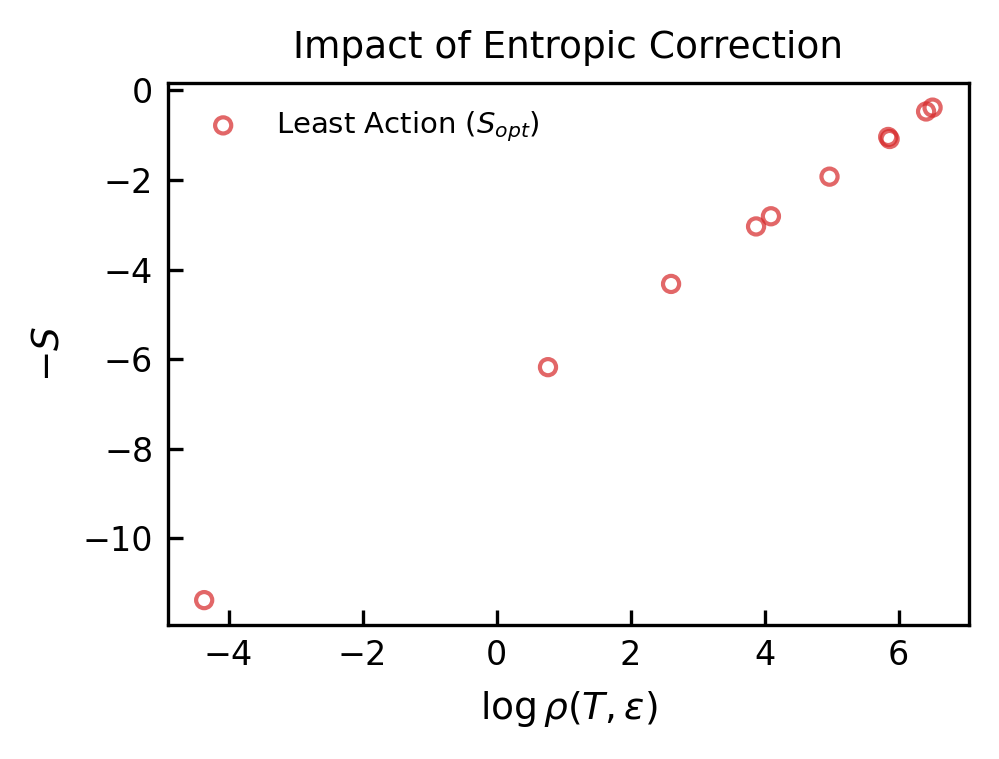

In [18]:
# -------------------------------------------------------------------------
# 2. Visualization
# -------------------------------------------------------------------------
# Use the styling provided
plt.rcParams.update({
    "font.size": 9,
    "axes.labelsize": 9,
    "axes.titlesize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "lines.markersize": 4,
    "figure.figsize": (3.4, 2.6),
    "figure.dpi": 300,
})

fig, ax = plt.subplots()

# A. Plot the original (Uncorrected) Least Action in Red
# We use hollow markers to distinguish them
sc1 = ax.scatter(log_rho_samp, -S_corr_vals-S_vals, 
                 label=r"Least Action ($S_{opt}$)",
                 color='tab:red', marker='o', facecolors='none', edgecolors='tab:red', 
                 alpha=0.7, s=15)

# B. Plot the Entropic Corrected Action in Blue
# These should shift towards the diagonal line
# sc2 = ax.scatter(log_rho_samp, -S_corr_vals-S_opt_vals, 
#                  label=r"Corrected ($S_{opt} + \frac{1}{2}\ln|\mathbf{H}|$)",
#                  color='tab:blue', marker='o', s=15, alpha=0.9)

# C. Add Identity Line (Ideal Prediction)
# If the approximation is perfect, points lie on this line: log(rho) = -S
# min_val = min(np.min(log_rho_samp), np.min(-S_corr_vals)) - 1
# max_val = max(np.max(log_rho_samp), np.max(-S_corr_vals)) + 1
# ax.plot([min_val, max_val], [min_val, max_val], 'k--', lw=1, alpha=0.5, label='Identity')

# Labels and Styling
ax.set_xlabel(r"$\log \rho(T,\epsilon)$")
ax.set_ylabel(r"$-S$")
ax.set_title("Impact of Entropic Correction")

# Create a clean legend
ax.legend(frameon=False, fontsize=7)
ax.tick_params(direction="in")
ax.grid(False)

# Adjust limits to data
# ax.set_xlim(min_val, max_val)
# ax.set_ylim(min_val, max_val)

fig.tight_layout()
plt.show()

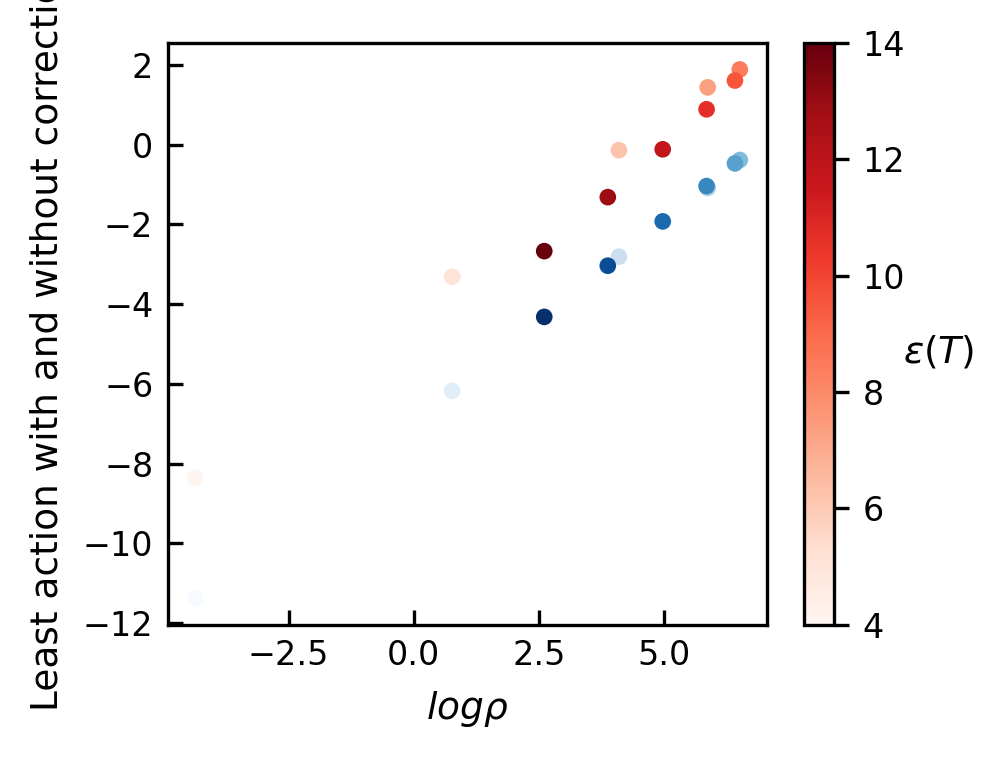

In [19]:
fig, ax = plt.subplots()
sc = ax.scatter(log_rho_samp,0+(-S_corr_vals-S_vals), c=h_samples, cmap="Blues", edgecolors="none")
sc = ax.scatter(log_rho_samp,0+(-S_vals), c=h_samples, cmap="Reds", edgecolors="none")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon(T)$", rotation=0, labelpad=8)

ax.set_xlabel(r"$log \rho$")
ax.set_ylabel("Least action with and without correction")
ax.tick_params(direction="in")
ax.grid(False)

fig.tight_layout()
plt.show()


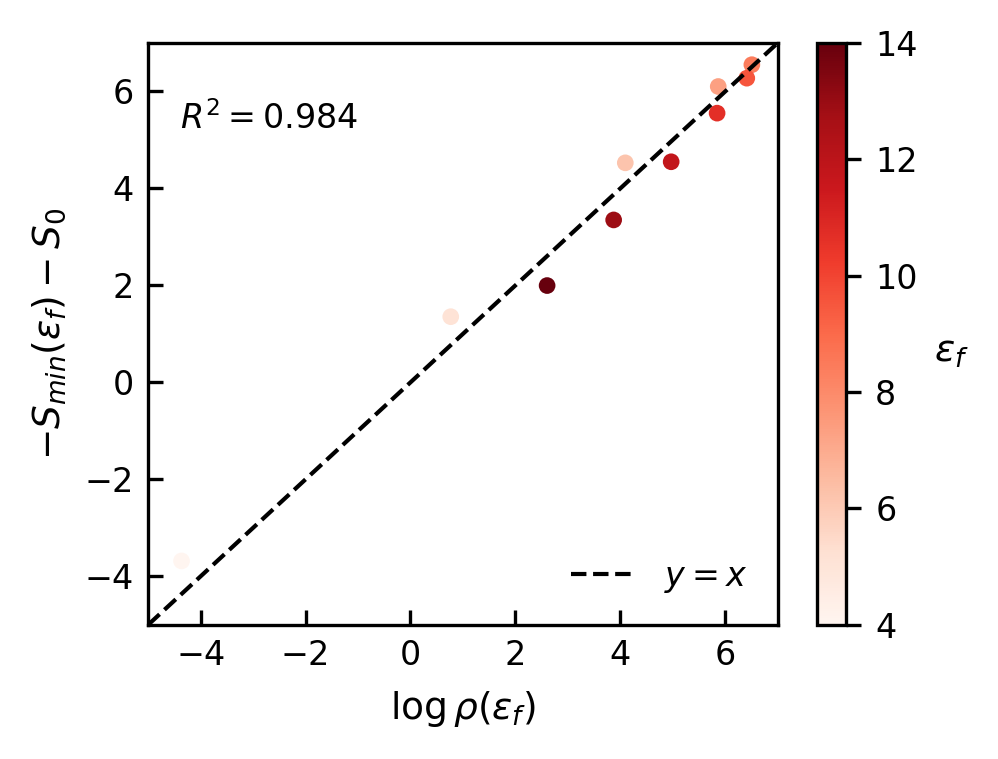

In [20]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

fig, ax = plt.subplots()

# --- Data Preparation (Series 2: S_min only) ---
y_vals = 0 + (-S_vals)
x_vals = log_rho_samp

# Fit regression (Used only for R^2 calculation now)
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
r_squared = r_value**2

# Calculate shift to center data on y=x (Mean difference)
shift = np.mean(y_vals - x_vals)

# Plot shifted data (y - shift)
sc = ax.scatter(x_vals, y_vals - shift, c=h_samples, cmap="Reds", 
                edgecolors="none")

# --- Add y=x line ---
# Create a range for the line based on the axis limits
line_range = np.linspace(-5, 7, 100)
ax.plot(line_range, line_range, 'k--', linewidth=1, label=r"$y=x$")

# --- Add R^2 text ---
# Placing text inside the plot area
ax.text(0.05, 0.9, f"$R^2={r_squared:.3f}$", transform=ax.transAxes, 
        fontsize=8, verticalalignment='top')

# --- Formatting ---
ax.legend(frameon=False, fontsize=8, loc='lower right')

# Colorbar
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon_f$", rotation=0, labelpad=8)

ax.set_xlabel(r"$\log \rho(\epsilon_f)$")
ax.set_ylabel(r"$-S_{min}(\epsilon_f)-S_0$")
ax.tick_params(direction="in")
ax.grid(False)
plt.xlim(-5, 7)
plt.ylim(-5, 7) # Matching ylim to xlim makes y=x appear clearly as a diagonal

fig.tight_layout()
plt.show()

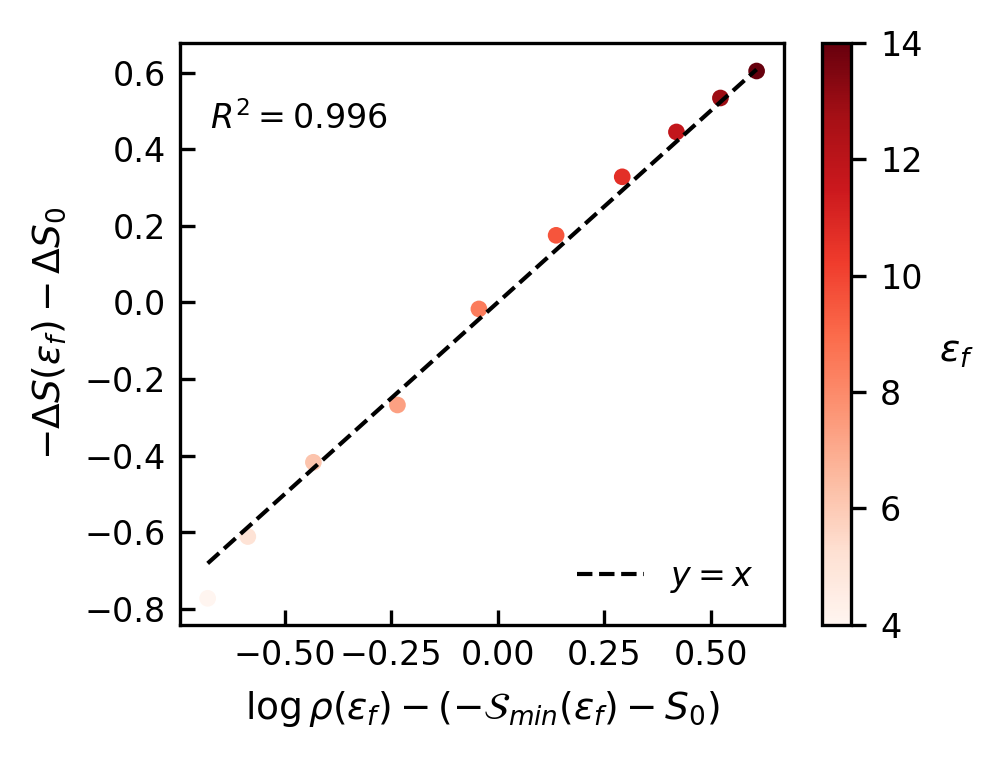

In [21]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import linregress

fig, ax = plt.subplots()

# --- Data Preparation ---
x_vals = log_rho_samp - (-S_vals-shift)
y_vals = -S_corr_vals

# --- 1. Linear Regression (Just for R^2 statistics) ---
slope, intercept, r_value, p_value, std_err = linregress(x_vals, y_vals)
r_squared = r_value**2

# --- 2. Calculate Alignment Shift ---
# Instead of subtracting the regression intercept, we subtract the mean difference.
# This forces the center of the data mass to lie exactly on y=x.
shift2 = np.mean(y_vals - x_vals) 
y_shifted = y_vals - shift2

# --- Plotting ---
sc = ax.scatter(x_vals, y_shifted, c=h_samples, cmap="Reds", edgecolors="none")

# Add y=x reference line
line_range = np.linspace(x_vals.min(), x_vals.max(), 100)
ax.plot(line_range, line_range, 'k--', linewidth=1, label=r"$y=x$")

# Add R^2 and Slope text annotation
# It is useful to note the slope is != 1
text_str = f"$R^2={r_squared:.3f}$"
ax.text(0.05, 0.9, text_str, transform=ax.transAxes, 
        fontsize=8, verticalalignment='top', )

# --- Formatting ---
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon_f$", rotation=0, labelpad=8)

ax.set_ylabel(r"$-\Delta S(\epsilon_f) -\Delta S_0$")
ax.set_xlabel(r"$\log \rho(\epsilon_f)-(-\mathcal{S}_{min}(\epsilon_f)-S_0$)")
ax.tick_params(direction="in")
ax.grid(False)
ax.legend(frameon=False, fontsize=8, loc='lower right')

fig.tight_layout()
plt.show()

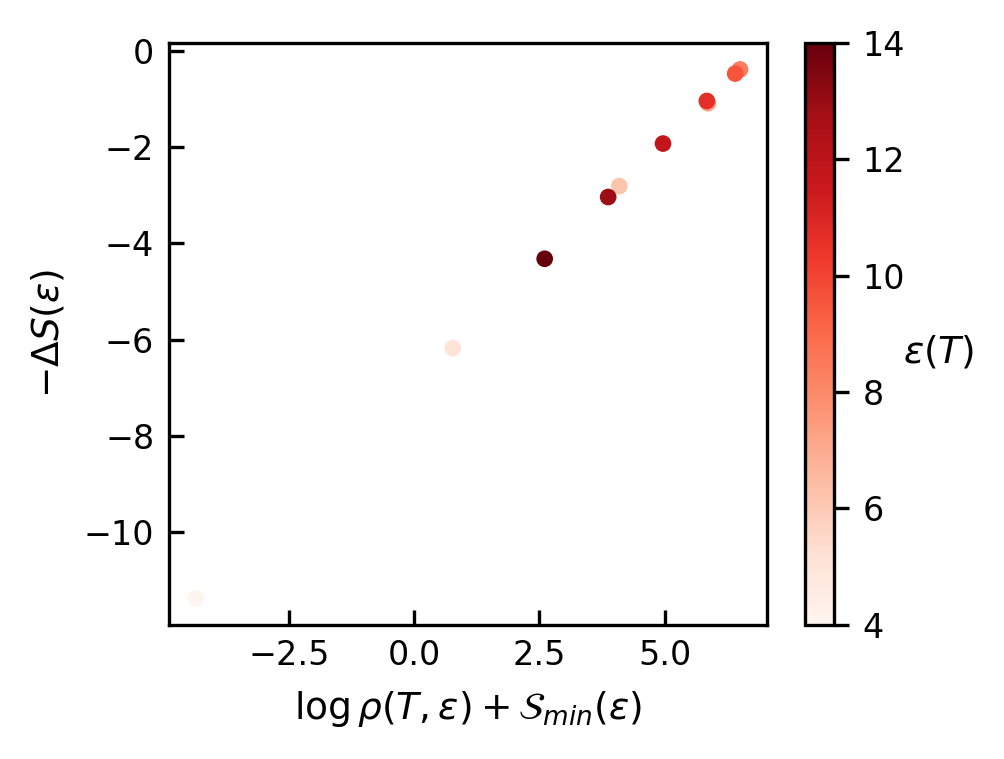

In [22]:
fig, ax = plt.subplots()
sc = ax.scatter(log_rho_samp, -S_vals-S_corr_vals ,c=h_samples, cmap="Reds", edgecolors="none")
# sc = ax.scatter(h_samples,log_rho_samp-(-S_vals+np.log(N_i)), c=h_samples, cmap="Reds", edgecolors="none")
cbar = plt.colorbar(sc, ax=ax)
cbar.set_label(r"$\epsilon(T)$", rotation=0, labelpad=8)

ax.set_ylabel(r"$-\Delta S(\epsilon)$")
ax.set_xlabel(r"$\log \rho(T,\epsilon)+\mathcal{S}_{min}(\epsilon)$")
# ax.set_title(r"Entropic correction")
ax.tick_params(direction="in")
ax.grid(False)

fig.tight_layout()
plt.show()

In [23]:
stop()

NameError: name 'stop' is not defined

# Obsolete?

# back to concentrations

# Same with pytorch

In [ ]:
import torch

def compute_least_action_torch(
    sol,
    fp_ctx,
    C_param,                  # torch.nn.Parameter, shape (n_times,) or scalar
    *, baseline=True, verbose=False, rtol=1e-8, atol=1e-10
):
    """
    PyTorch replica of `compute_least_action` with a learnable C(t).

    Returns
    -------
    S_opt            – torch scalar (action along optimal path)
    S_lin (optional) – torch scalar (linear-path action) if baseline=True
    """

    # --------------------------------------------------------------
    # 0 · unpack & sanity-check
    # --------------------------------------------------------------
    dtype   = torch.float64
    device  = C_param.device

    times   = torch.as_tensor(fp_ctx["times"],   dtype=dtype, device=device)
    omegas0 = torch.as_tensor(fp_ctx["omegas"],  dtype=dtype, device=device)   # reference
    Phi0    = torch.as_tensor(fp_ctx["Phi_bar"], dtype=dtype, device=device)   # reference

    rho_np  = fp_ctx["rho_t"]                         # list of numpy arrays (…grid…)
    axes_np = fp_ctx["axes"]                          # tuple of 1-D axes
    S_mat   = torch.as_tensor(fp_ctx["S_mat"], dtype=dtype, device=device)


    n_times = times.numel()
    N_h, n_A = S_mat.shape

    # broadcast C_param
    if C_param.ndim == 0:
        C_t = C_param.expand(n_times)
    elif C_param.numel() == n_times:
        C_t = C_param
    else:
        raise ValueError("C_param must be scalar or length n_times")

    # grid constants
    d_h  = axes_np[0][1] - axes_np[0][0]
    dH   = d_h ** N_h
    axes_t = [torch.as_tensor(ax, dtype=dtype, device=device) for ax in axes_np]
    H_mesh = torch.meshgrid(*axes_t, indexing="ij")
    H_stack= torch.stack(H_mesh, dim=0)                       # (N_h,*grid)

    E_stack     = torch.tensordot(S_mat.T, H_stack, dims=([1],[0]))  # (n_A,*grid)
    exp_E       = torch.exp(E_stack / kBT)
    exp_Eshift  = torch.exp((E_stack - E_a) / kBT)

    Phi_grid       = exp_E.sum(dim=0)         # Σ_v e^{E_v/kBT}
    PAg_numer_grid = exp_Eshift               # Σ_v e^{(E_v-E_a)/kBT}

    rho_t = [torch.as_tensor(r, dtype=dtype, device=device) for r in rho_np]

    # --------------------------------------------------------------
    # 1 · recompute Φ̄(t_k) and Ω(t_k) with the supplied C(t)
    # --------------------------------------------------------------
    Phi_bar = torch.empty_like(times)
    Omega   = torch.empty_like(times)

    for k in range(n_times):
        Ck       = C_t[k]                           # scalar (requires_grad)
        N_pop    = rho_t[k].sum() * dH

        # Φ̄(t_k)  (independent of C)
        Phi_bar_k = (rho_t[k] * Phi_grid).sum() * dH / N_pop
        Phi_bar[k] = Phi_bar_k

        # selection log-gain per grid point
        numer_PAg = Ck * PAg_numer_grid
        P_Ag_grid = numer_PAg / (1. + numer_PAg)

        C_tot     = n_A * Ck
        P_T_grid  = Phi_grid / (Phi_grid + Phi_bar_k / C_tot)

        log_sel   = torch.log(P_Ag_grid) + torch.log(P_T_grid)
        avg_log   = (rho_t[k] * log_sel).sum() * dH / N_pop

        if N_pop < N_max+0.1:
            Omega[k] = 0.0
        else:
            Omega[k] = torch.maximum(torch.zeros((), dtype=dtype, device=device),
                                     lam + avg_log)

    # --------------------------------------------------------------
    # 2 · debug: compare with reference values (optional)
    # --------------------------------------------------------------
    if verbose:
        phi_diff   = torch.max(torch.abs(Phi_bar - Phi0) / Phi0.clamp_min(1e-12))
        omega_diff = torch.max(torch.abs(Omega   - omegas0) /
                               omegas0.clamp_min(1e-12))
        print(f"max rel error Φ̄: {phi_diff.item():.3e}")
        print(f"max rel error Ω : {omega_diff.item():.3e}")

        #show indexes of biggest differences
        if phi_diff > rtol or omega_diff > rtol:
            idx_phi = torch.argmax(torch.abs(Phi_bar - Phi0) / Phi0.clamp_min(1e-12))
            idx_omega = torch.argmax(torch.abs(Omega - omegas0) /
                                     omegas0.clamp_min(1e-12))
            print(f"max Φ̄ diff at index {idx_phi.item()}: "
                  f"{Phi_bar[idx_phi].item():.3e} vs {Phi0[idx_phi].item():.3e}")
            print(f"max Ω  diff at index {idx_omega.item()}: "
                  f"{Omega[idx_omega].item():.3e} vs {omegas0[idx_omega].item():.3e}")


    # assert close enough (can be relaxed)
    # torch.testing.assert_close(Phi_bar, Phi0, rtol=rtol, atol=atol)
    # torch.testing.assert_close(Omega,   omegas0, rtol=rtol, atol=atol)

    # --------------------------------------------------------------
    # 3 · extract optimal trajectory (SciPy solution)
    # --------------------------------------------------------------
    t_mesh = torch.as_tensor(sol.x,              dtype=dtype, device=device)  # (m,)
    h_opt  = torch.as_tensor(sol.y[:N_h].T,      dtype=dtype, device=device)  # (m,N_h)
    v_opt  = torch.as_tensor(sol.y[N_h:2*N_h].T, dtype=dtype, device=device)  # (m,N_h)

    v_pref = torch.full((N_h,), f_aa * mu_M, dtype=dtype, device=device)

    def idx(t):
        return torch.argmin(torch.abs(times - t))

    # --------------------------------------------------------------
    # 4 · Γ(t,h) using the new Ω and Φ̄
    # --------------------------------------------------------------
    def Gamma(t, h):
        k       = idx(t)
        omega_k = Omega[k]
        Phi_b   = Phi_bar[k]
        Ck      = C_t[k]
        C_vec   = Ck.expand(n_A)

        E_v = torch.mv(S_mat.T, h)
        P_Ag = (C_vec * torch.exp((E_v - E_a) / kBT)).sum()
        P_Ag = P_Ag / (1. + P_Ag)

        Phi  = torch.exp(E_v / kBT).sum()
        P_T  = Phi / (Phi + Phi_b / (n_A * Ck))

        return lam + torch.log(P_Ag) + torch.log(P_T) - omega_k

    # --------------------------------------------------------------
    # 5 · action functional
    # --------------------------------------------------------------
    def S_of(h, v):
        g_vals = torch.stack([Gamma(ti, hi) for ti, hi in zip(t_mesh, h)])  # (m,)
        kin    = ((v - v_pref).pow(2).sum(dim=1)) / (2. * D)               # (m,)
        return -torch.trapz(g_vals - kin, t_mesh)

    S_opt = S_of(h_opt, v_opt)

    if not baseline:
        return S_opt

    # linear reference
    slope  = h_opt[-1] / (t_mesh[-1] - t_mesh[0])
    h_lin  = (t_mesh[:, None] - t_mesh[0]) * slope
    v_lin  = slope.repeat(t_mesh.numel(), 1)
    S_lin  = S_of(h_lin, v_lin)

    return S_opt, S_lin


In [ ]:
S_mat = np.array([[1.]], dtype=float)   # two shape coords, 1 Ag
hf     = [8]  
c=10
def get_C(t, v):
        return c
fp_ctx = run_fp(
        S_mat=np.array([[1.0]]),  # 2D shape space: h₁ and h₂
        get_C=get_C,
        T=60,
        verbose=False
    )
fp_ctx["get_C"] = get_C

# --- 2. least‑action path to hf ----------------------------
sol = solve_optimal_trajectory(hf, fp_ctx, plot=False, mesh=100)


# C_param = torch.tensor(float(10), dtype=torch.float64, requires_grad=True)
# --- 1. fresh FP run with the *current* C -------------------
                                             # scalar float
# --- 3. action + gradient wrt C ----------------------------
init_C=c
times      = torch.tensor(fp_ctx["times"],  dtype=torch.float64)

n_times    = len(times)
C_param = torch.nn.Parameter(
        torch.full((n_times,), init_C, dtype=torch.float64)
    )

S_opt_np = compute_least_action(sol, fp_ctx, baseline=True, verbose=True)
print('np',S_opt_np)
S_opt, S_lin = compute_least_action_torch(
    sol, fp_ctx, C_param=C_param, baseline=True, verbose=True)
print('torch',S_opt)
print('torch lin',S_lin)


S_opt = 6.307809e-01   S_lin = 1.008288e+01   ΔS = 9.452101e+00
np (0.6307809344896917, 10.082882242013639)
max rel error Φ̄: 8.361e-16
max rel error Ω : 3.563e+11
max Φ̄ diff at index 3562: 1.190e+02 vs 1.190e+02
max Ω  diff at index 4854: 3.563e-01 vs 0.000e+00
torch tensor(0.6308, dtype=torch.float64, grad_fn=<NegBackward0>)
torch lin tensor(10.0829, dtype=torch.float64, grad_fn=<NegBackward0>)


In [ ]:
S_opt_np = compute_least_action(sol, fp_ctx, baseline=False, verbose=True)
print('np',S_opt_np)

S_opt = 6.307809e-01
np 0.6307809344896917


In [ ]:
S_opt, dS_dC = compute_least_action_torch(
    sol, fp_ctx, C_param=C_param, baseline=True, verbose=True)
print('torch',S_opt)

max rel error Φ̄: 8.361e-16
max rel error Ω : 3.563e+11
max Φ̄ diff at index 3562: 1.190e+02 vs 1.190e+02
max Ω  diff at index 4854: 3.563e-01 vs 0.000e+00
torch tensor(0.6308, dtype=torch.float64, grad_fn=<NegBackward0>)


# Different concentrations

In [ ]:
import numpy as np, torch, copy, math, os, warnings
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
warnings.filterwarnings("ignore", category=UserWarning,
                        message="KMP_DUPLICATE_LIB_OK")

# ---------------------------------------------------------------------
# optimise_multiC_20  – 20 log-concentration parameters over whole span
# ---------------------------------------------------------------------
def optimise_multiC_20(
    hf, S_mat, *,
    C0        = 5.0,      # initial concentration in every bin
    lr        = 0.20,     # learning-rate in log-space
    n_steps   = 25,
    tol       = 1e-4,
    T         = 60.0,     # FP horizon
    verbose   = True, 
    n=20 #nb of bins
):
    """
    Learns 20 parameters L_bins = log C_bins such that
        C(t) = exp(L_bins[bin_of(t)]).
    The 20 bins partition the total FP time span uniformly.
    """
    # ------------------------------------------------------------------
    # ① Build once the FP time grid & snapshot → bin mapping
    # ------------------------------------------------------------------
    fp_probe = run_fp(S_mat, lambda t, v: C0, T=T, verbose=False)
    times_np = np.asarray(fp_probe["times"])

    t0, tf   = times_np[0], times_np[-1]
    bin_width = (tf - t0) / n                       # Δt per bin

    bin_idx = torch.tensor(
        np.clip(np.floor((times_np - t0) / bin_width).astype(int), 0, n-1),
        dtype=torch.long
    )

    # 20 learnable *log*-concentrations
    L_bins = torch.full((n,),
                        math.log(C0),
                        dtype=torch.float64,
                        requires_grad=True)

    hist_C, hist_S = [], []                            # diagnostics

    for it in range(n_steps):
        if verbose:
            print(f"\n▶ iteration {it+1:02d}/{n_steps}")

        # --------------------------------------------------------------
        # ② Build per-snapshot concentration tensor (keeps grad)
        # --------------------------------------------------------------
        C_bins  = torch.exp(L_bins)          # (20,) positive, grad-aware
        C_param = C_bins[bin_idx]            # (n_times,)

        # --------------------------------------------------------------
        # ③ Run FP with detached numbers
        # --------------------------------------------------------------
        C_det = C_bins.detach().cpu().numpy()

        def get_C_piece(t, v, C_arr=C_det, t0=t0, bw=bin_width):
            idx = int((t - t0) // bw)
            if idx > n-1:
                idx = n-1
            return float(C_arr[idx])

        # Differentiable lookup
        def get_C_granular(t, v, C_arr=C_param, t0=t0, bw=bin_width):
            idx = int((t - t0) // bw)
            if idx > n-1:
                idx = n-1
            return C_arr[idx]                # Tensor → keeps grad

        fp_ctx = run_fp(S_mat, get_C_piece, T=T, verbose=False)
        fp_ctx["get_C"] = get_C_granular

        # --------------------------------------------------------------
        # ④ Optimal trajectory on same mesh
        # --------------------------------------------------------------
        sol = solve_optimal_trajectory(
            hf, copy.deepcopy(fp_ctx), mesh=200, plot=False
        )

        # --------------------------------------------------------------
        # ⑤ Action & gradient wrt L_bins
        # --------------------------------------------------------------
        S_opt, S_lin = compute_least_action_torch(
            sol, fp_ctx, C_param=C_param,
            baseline=True,     # <- now the function returns both values
            verbose=False
        )


        if L_bins.grad is not None:
            L_bins.grad.zero_()
        S_opt.backward()

        grad_L = L_bins.grad.detach().clone()      # (20,)

        # ------------------------------------------------ diagnostics --
        gmax = grad_L.abs().max().item()
        if verbose:
            print(f"   S = {S_opt.item():.6e}    ‖∇S‖_∞ = {gmax:.2e}")
            print("   C_bins :", C_bins.detach().cpu().numpy())
            print("   log(C) :", L_bins.detach().cpu().numpy())
            print("   grad log:", grad_L.cpu().numpy())

        hist_C.append(C_bins.detach().cpu().numpy().copy())
        hist_S.append(S_opt.item())

        if gmax < tol:
            if verbose:
                print("   ✅ gradient below tolerance – stopping.")
            break

        # --------------------------------------------------------------
        # ⑥ Gradient step in log-space
        # --------------------------------------------------------------
        with torch.no_grad():
            L_bins -= lr * grad_L
            L_bins.clamp_(min=-20.0)   # exp(-20) ≈ 2e-9 → keeps >0

        L_bins.grad = None             # clear for next loop

    return (np.array(hist_C), np.array(hist_S)), torch.exp(L_bins)


In [ ]:
S_mat = np.array([[1.]], dtype=float)   # two h‑coords, one antigen
hf    = [8]
n=10
T=30
(history, C_final) = optimise_multiC_20(
    hf, S_mat,
    C0=20., lr=0.2, n_steps=20, tol=1e-4, verbose=True, T=T, n=n
)

print("\nOptimised 20‑bin C values:")
print(np.round(C_final.detach().cpu().numpy(), 3))



▶ iteration 01/20
   S = 1.583476e+01    ‖∇S‖_∞ = 1.66e+00
   C_bins : [20. 20. 20. 20. 20. 20. 20. 20. 20. 20.]
   log(C) : [2.99573227 2.99573227 2.99573227 2.99573227 2.99573227 2.99573227
 2.99573227 2.99573227 2.99573227 2.99573227]
   grad log: [-1.65951981 -0.95683328 -0.49509033 -0.25027609 -0.12654197 -0.06454275
 -0.03329609 -0.01738848 -0.00919069 -0.00482559]

▶ iteration 02/20
   S = 1.599982e+01    ‖∇S‖_∞ = 1.41e+00
   C_bins : [27.87238002 24.21806709 22.08172492 21.02658294 20.51262739 20.2598445
 20.13362881 20.06967502 20.03679658 20.01931166]
   log(C) : [3.32763624 3.18709893 3.09475034 3.04578749 3.02104067 3.00864082
 3.00239149 2.99920997 2.99757041 2.99669739]
   grad log: [-1.41022342 -0.8535729  -0.46748867 -0.24485003 -0.12591234 -0.06460344
 -0.03333158 -0.01735787 -0.00913505  0.49110389]

▶ iteration 03/20
   S = 1.614993e+01    ‖∇S‖_∞ = 1.21e+00
   C_bins : [36.95425952 28.72631235 24.24591318 22.08188299 21.03574503 20.52331406
 20.26829432 20.13946946 

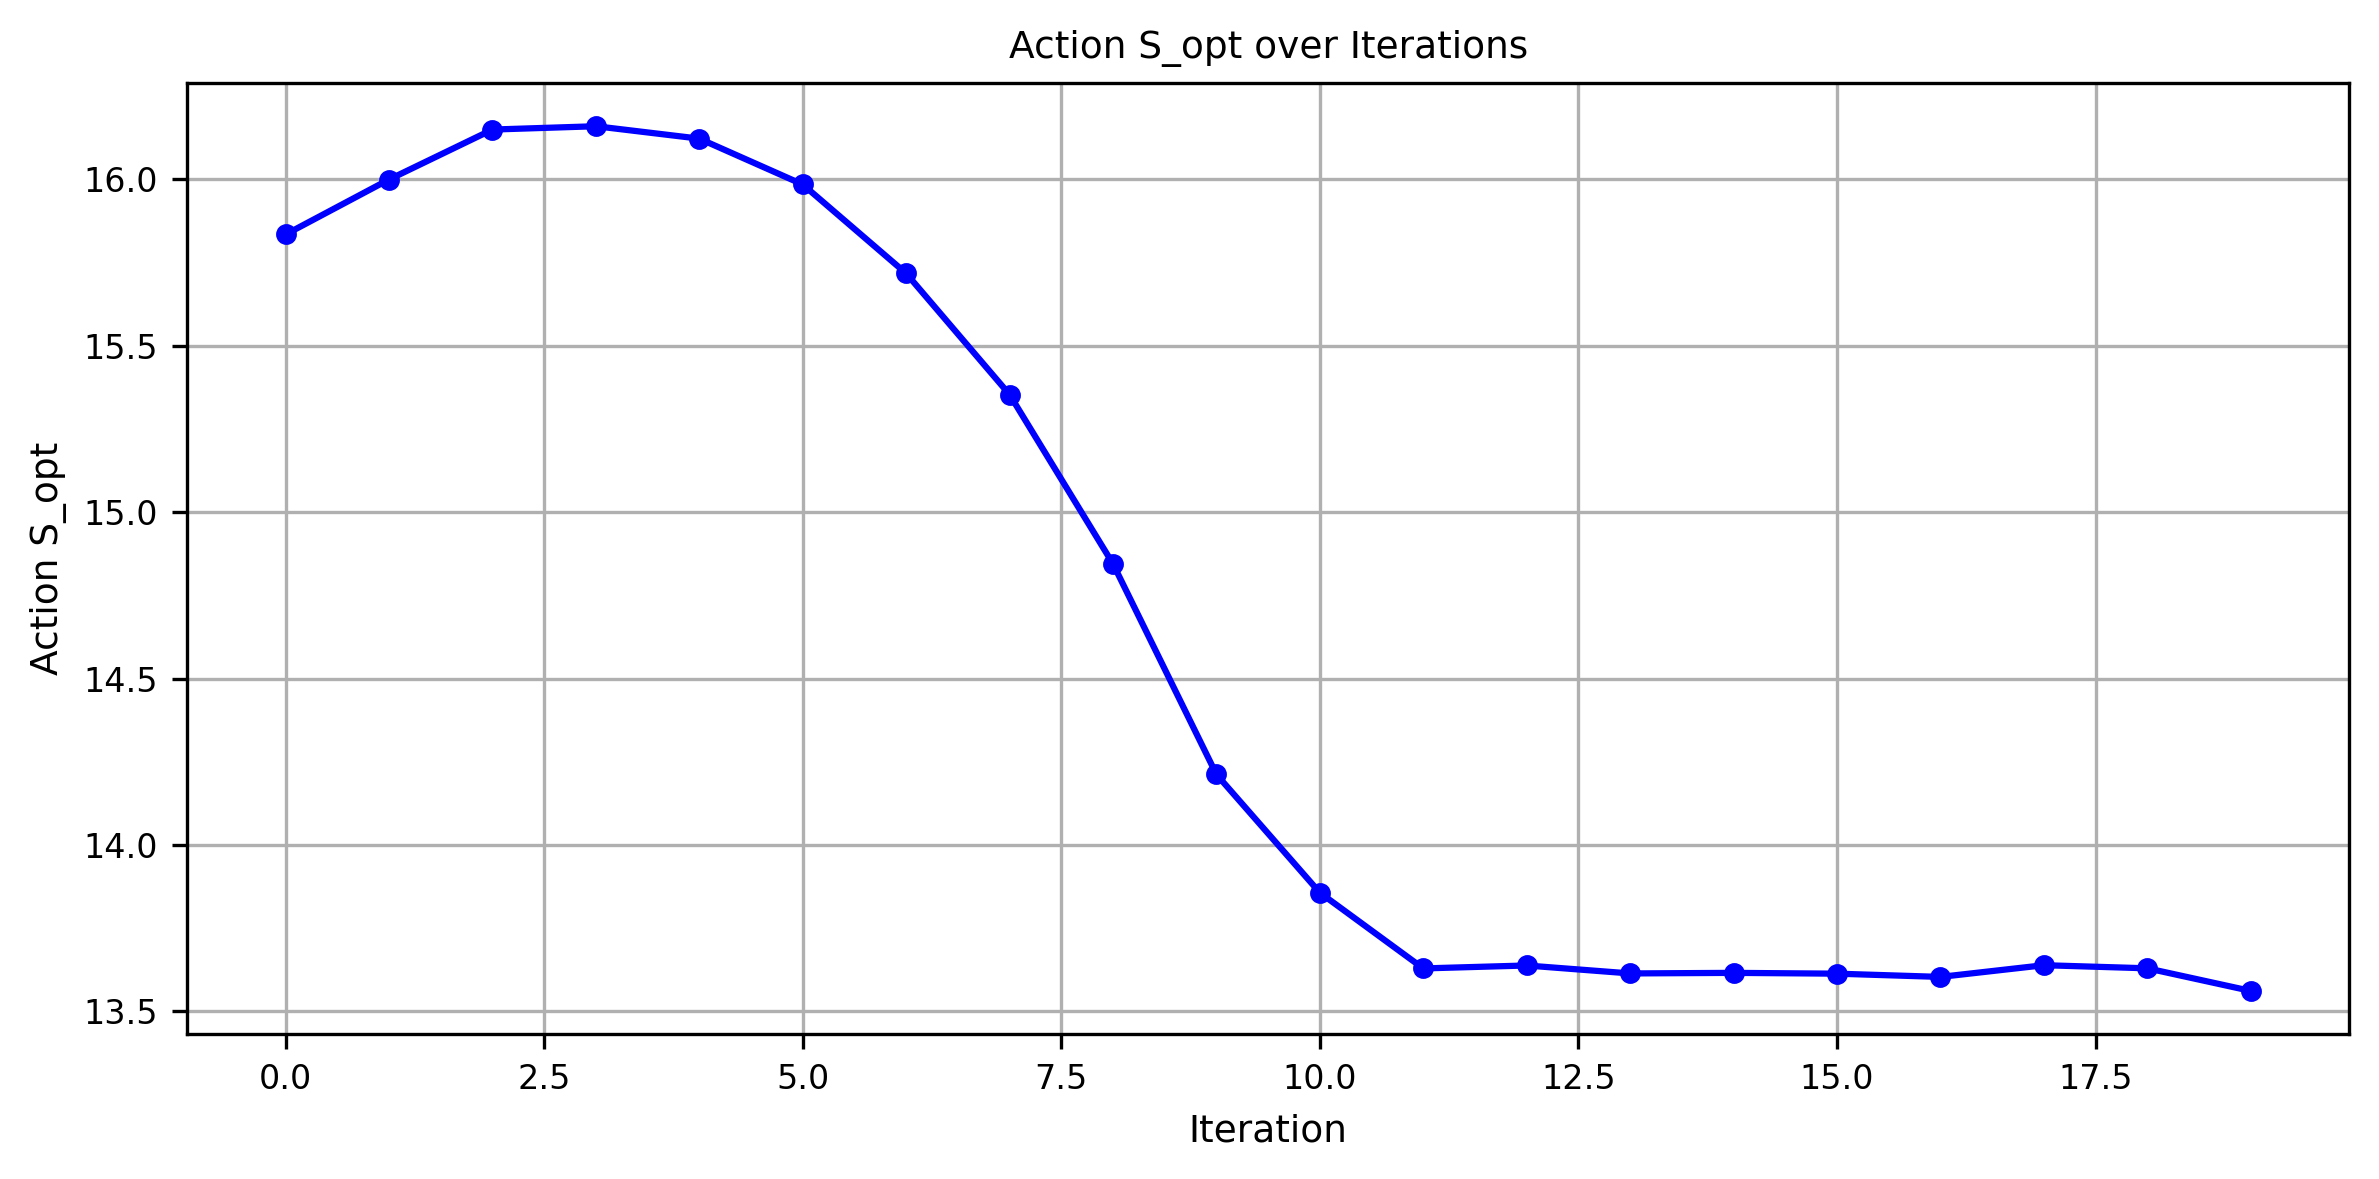

In [ ]:
history[1]#plot
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.plot(history[1], marker='o', linestyle='-', color='blue')
plt.title("Action S_opt over Iterations")
plt.xlabel("Iteration")
plt.ylabel("Action S_opt")
plt.grid(True)
plt.tight_layout()
plt.show()



    1  t=  0.01  N=  2500.0  Ω=  0.000  ⟨Γ⟩=   0.073  ⟨h_1⟩= -0.00
    2  t=  0.02  N=  2501.8  Ω=  0.073  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    3  t=  0.03  N=  2501.8  Ω=  0.073  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    4  t=  0.04  N=  2501.8  Ω=  0.073  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    5  t=  0.05  N=  2501.8  Ω=  0.073  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    6  t=  0.06  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    7  t=  0.07  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    8  t=  0.08  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    9  t=  0.09  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
   10  t=  0.10  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
   11  t=  0.11  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
   12  t=  0.12  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
   13  t=  0.13  N=  2501.8  Ω=  0.072  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
   14  t=  0.14  N=  2501.8  Ω=  0.071  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
   15  t=  0.15  N=  2501.8  Ω=  0.071  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -

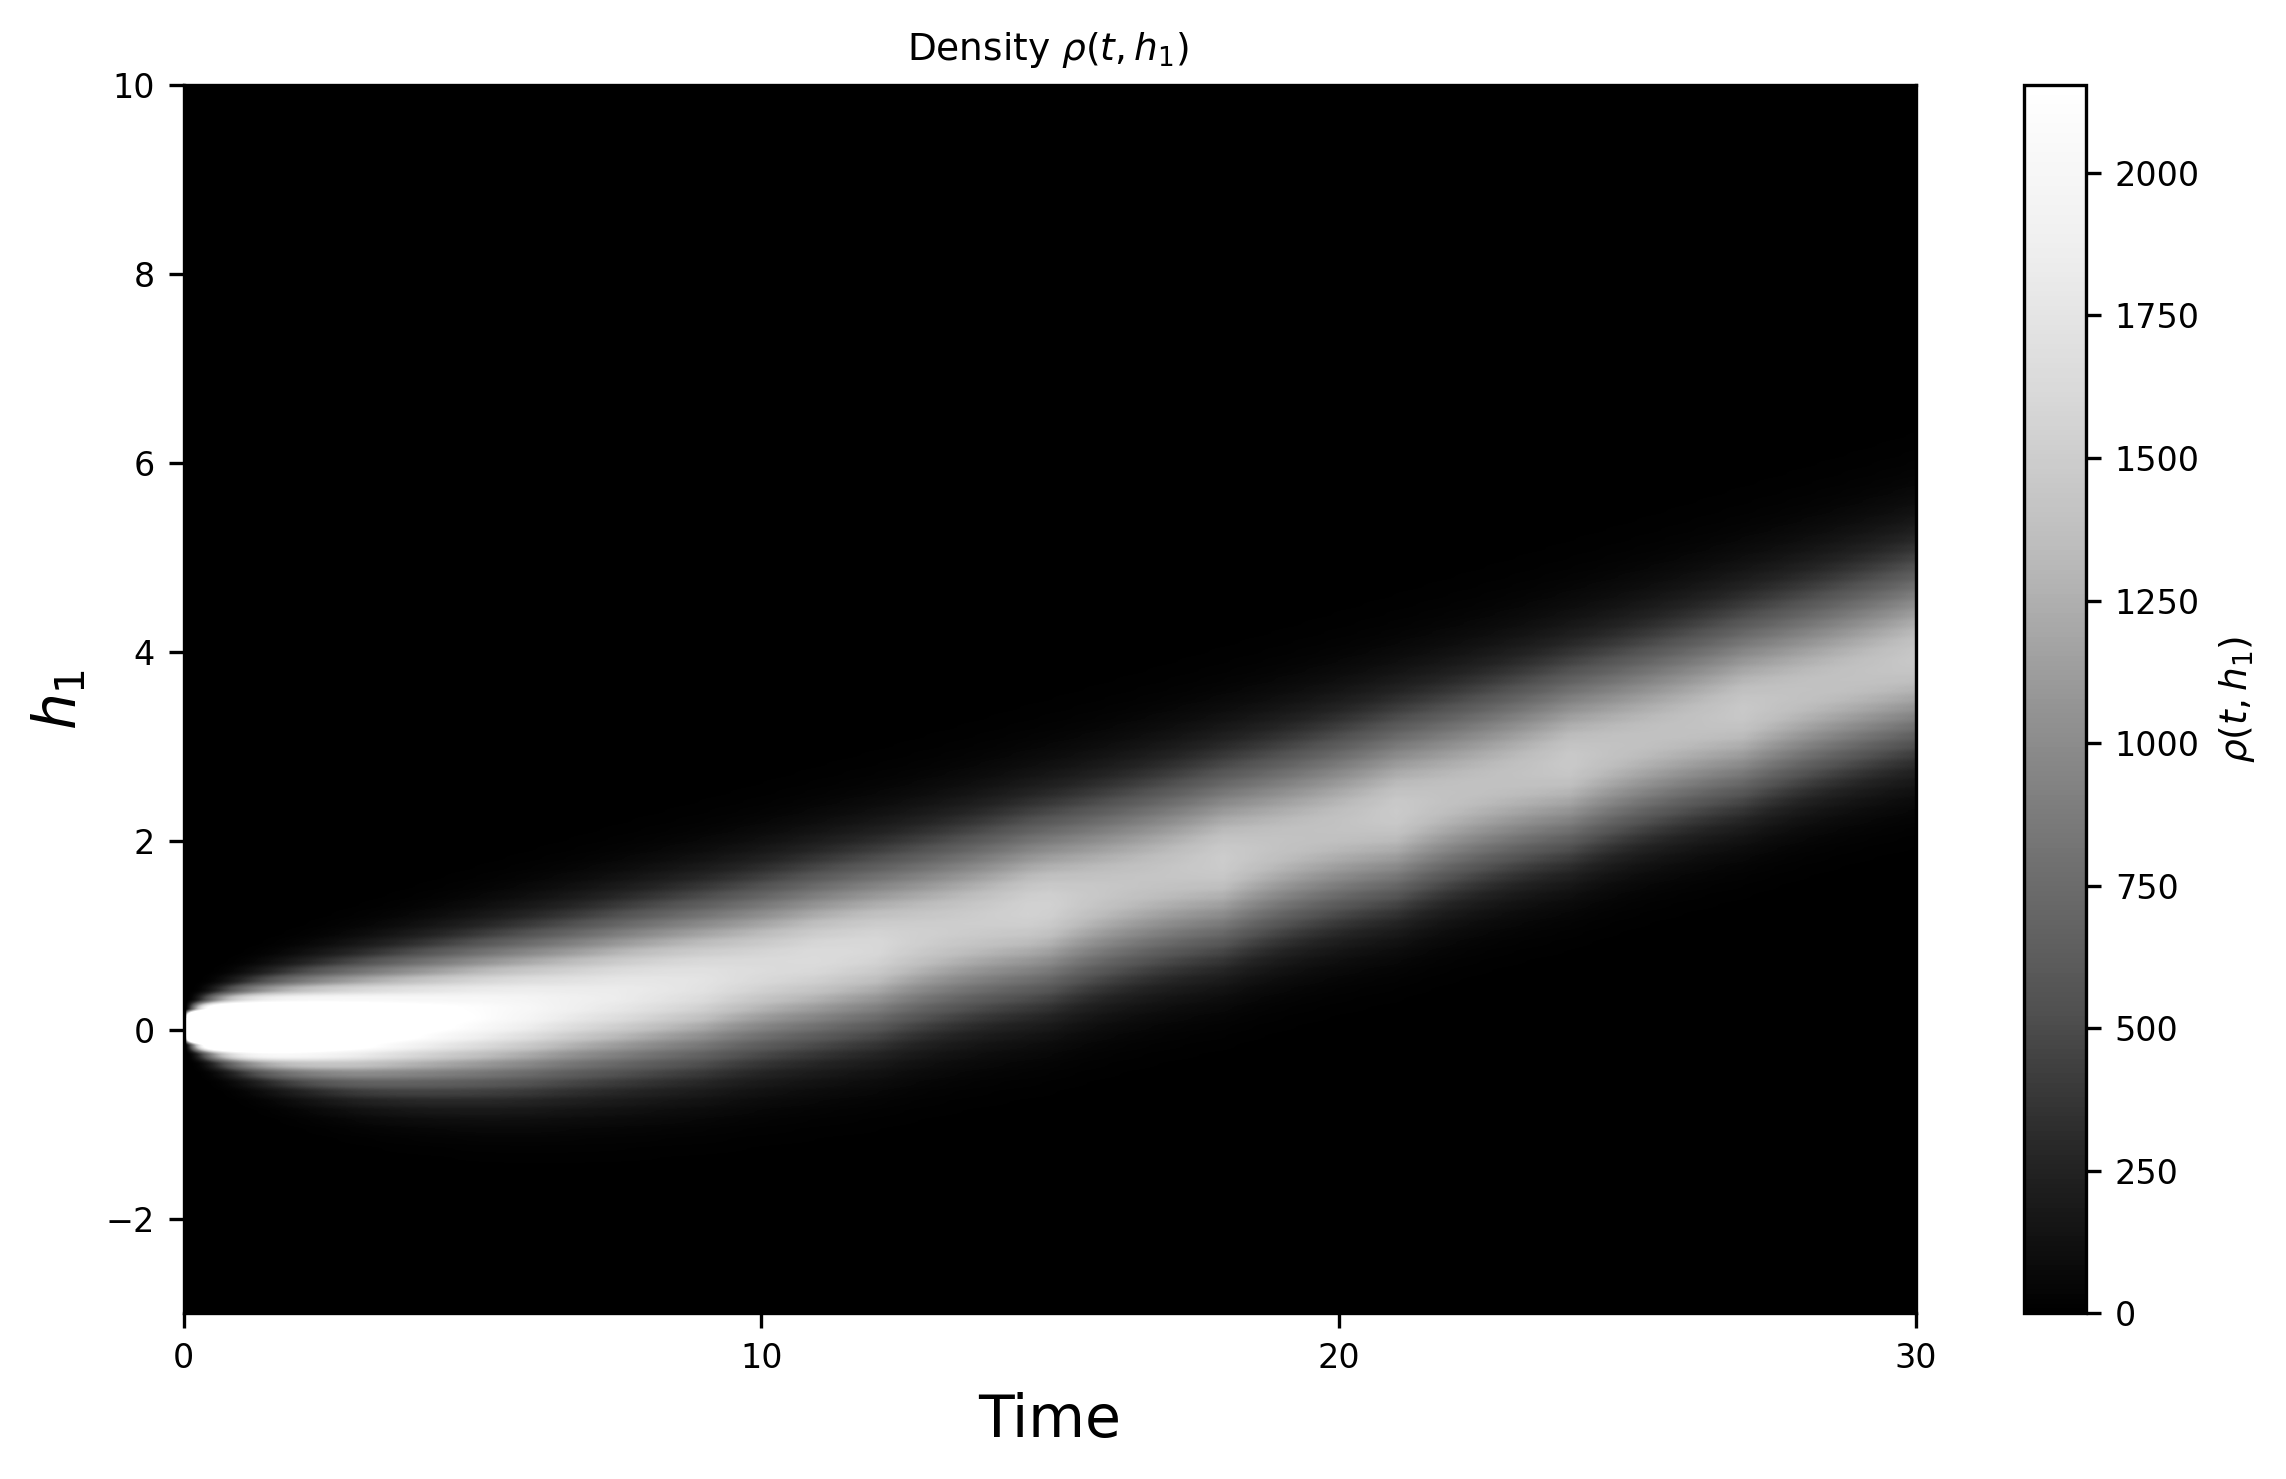

S_opt = 1.364324e+01   S_lin = 1.384598e+01   ΔS = 2.027377e-01


In [ ]:
# ------------------------------------------------------------------
# 1. Extract times from a dummy FP run to build bin mapping
# ------------------------------------------------------------------
fp_probe = run_fp(S_mat, lambda t, v: 5, T=T, verbose=False)
times_np = np.asarray(fp_probe["times"])
t0, tf   = times_np[0], times_np[-1]
n_bins   = len(C_final)
bin_width = (tf - t0) / n_bins

# ------------------------------------------------------------------
# 2. Define a concentration function using the optimized bins
# ------------------------------------------------------------------
C_final_np = C_final.detach().cpu().numpy()

def get_C_final(t, v):
    idx = int((t - t0) // bin_width)
    if idx >= n_bins:
        idx = n_bins - 1
    return float(C_final_np[idx])

# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C_final, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, disp_step=10, cmap="Greys_r")
S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results={}
results['copt']=fp_ctx_safe


NameError: name 'C_star' is not defined

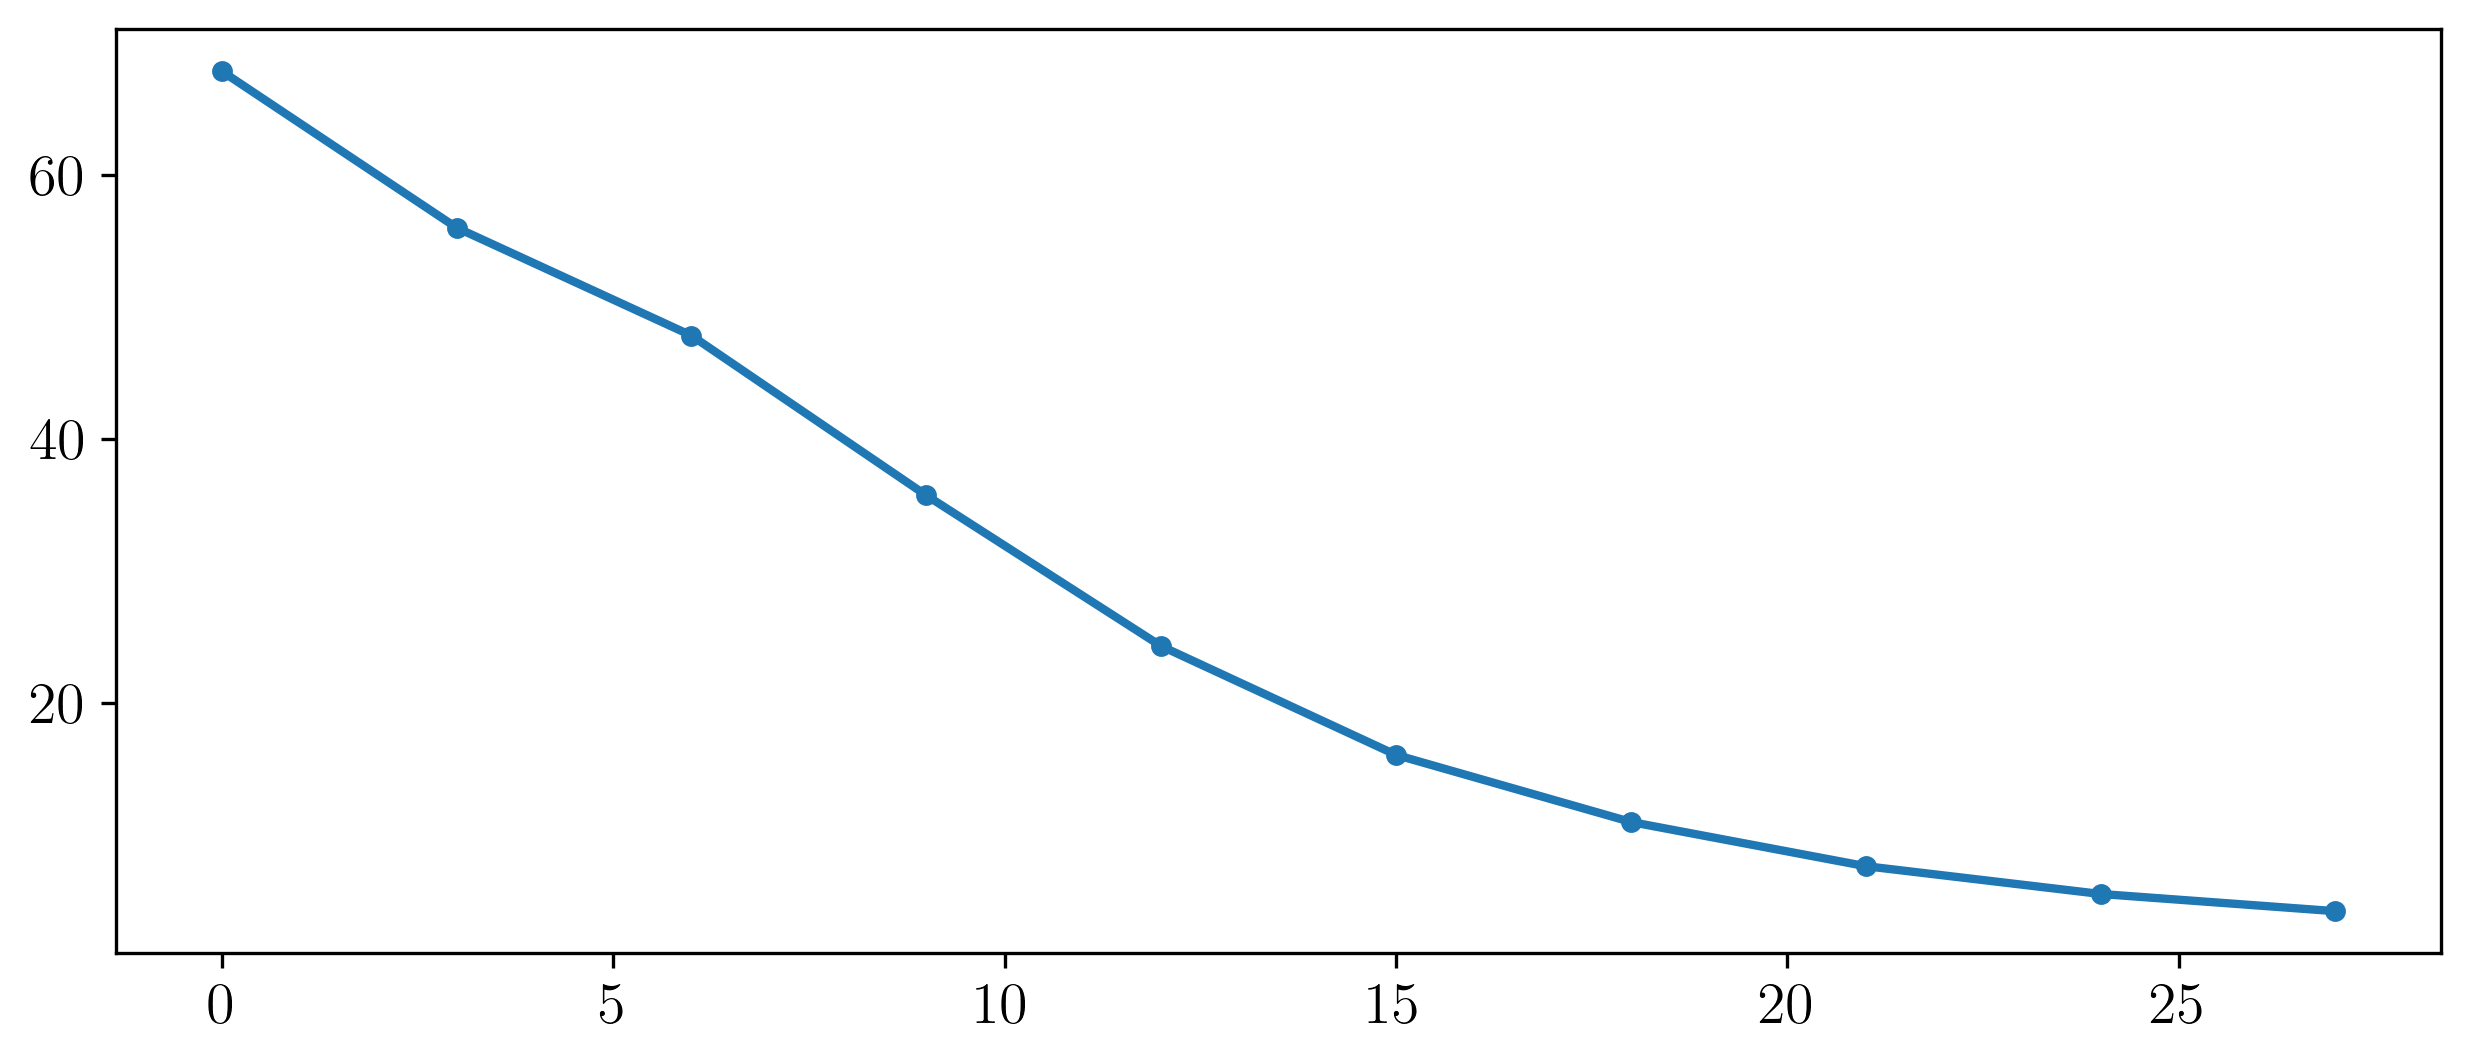

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import torch

# Convert tensor to NumPy array
C_np = C_final.detach().cpu().numpy()

# Value of C* (you must define this earlier in your code)

# Set large figure and font sizes
plt.figure(figsize=(10, 4))
plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 18,
    "axes.titlesize": 20,
    "legend.fontsize": 14,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "text.usetex": True,
    "font.family": "serif"
})

# Plot optimized C(t)
plt.plot(np.arange(0, len(C_np)) * T / n, C_np, marker='o', lw=2)

# Horizontal line at C*
plt.axhline(C_star, color='k', linestyle='--', linewidth=1.5, label=fr"$C^\circ \approx {C_star:.2g}$")

# Labels and formatting
plt.title(r"\textbf{Optimized Concentration per Time Bin}")
plt.xlabel(r"\textbf{Time (12\,h)}")
plt.ylabel(r"\textbf{Concentration (nM)}")
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=  -0.613  ⟨h_1⟩= -0.00
    2  t=  0.02  N=  1987.7  Ω=  0.000  ⟨Γ⟩=  -0.614  ⟨h_1⟩= -0.00
    3  t=  0.03  N=  1975.4  Ω=  0.000  ⟨Γ⟩=  -0.615  ⟨h_1⟩= -0.00
    4  t=  0.04  N=  1963.2  Ω=  0.000  ⟨Γ⟩=  -0.616  ⟨h_1⟩= -0.00
    5  t=  0.05  N=  1951.0  Ω=  0.000  ⟨Γ⟩=  -0.616  ⟨h_1⟩= -0.00
    6  t=  0.06  N=  1939.0  Ω=  0.000  ⟨Γ⟩=  -0.617  ⟨h_1⟩= -0.00
    7  t=  0.07  N=  1926.9  Ω=  0.000  ⟨Γ⟩=  -0.618  ⟨h_1⟩= -0.00
    8  t=  0.08  N=  1915.0  Ω=  0.000  ⟨Γ⟩=  -0.619  ⟨h_1⟩= -0.00
    9  t=  0.09  N=  1903.1  Ω=  0.000  ⟨Γ⟩=  -0.619  ⟨h_1⟩= -0.01
   10  t=  0.10  N=  1891.2  Ω=  0.000  ⟨Γ⟩=  -0.620  ⟨h_1⟩= -0.01
   11  t=  0.11  N=  1879.4  Ω=  0.000  ⟨Γ⟩=  -0.621  ⟨h_1⟩= -0.01
   12  t=  0.12  N=  1867.7  Ω=  0.000  ⟨Γ⟩=  -0.621  ⟨h_1⟩= -0.01
   13  t=  0.13  N=  1856.0  Ω=  0.000  ⟨Γ⟩=  -0.622  ⟨h_1⟩= -0.01
   14  t=  0.14  N=  1844.4  Ω=  0.000  ⟨Γ⟩=  -0.623  ⟨h_1⟩= -0.01
   15  t=  0.15  N=  1832.9  Ω=  0.000  ⟨Γ⟩=  -0.623  ⟨h_1⟩= -

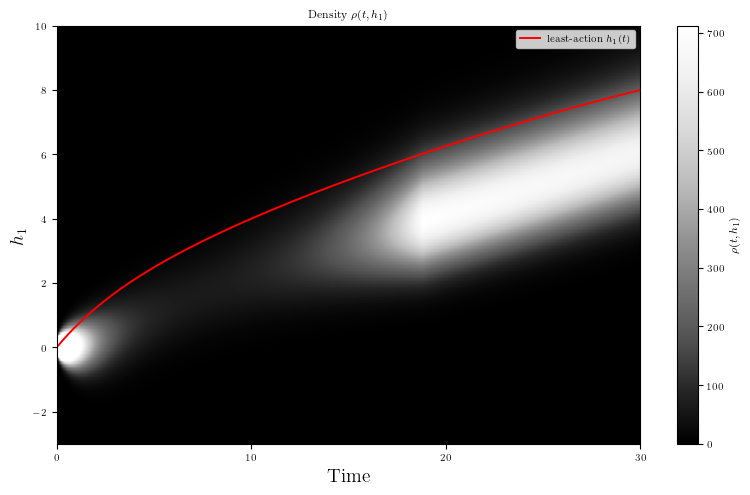

S_opt = 1.348912e-01   S_lin = 2.619241e+00   ΔS = 2.484350e+00


In [ ]:
def get_C(t, v):
    return C_final.mean().item()  # Use the mean of the optimized concentrations

# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, sol=sol, disp_step=10, cmap="Greys_r")
S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results['mean']=fp_ctx_safe

    1  t=  0.01  N=  2000.0  Ω=  0.000  ⟨Γ⟩=   0.478  ⟨h_1⟩= -0.00
    2  t=  0.02  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    3  t=  0.03  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    4  t=  0.04  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    5  t=  0.05  N=  2009.5  Ω=  0.476  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    6  t=  0.06  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    7  t=  0.07  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.00
    8  t=  0.08  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
    9  t=  0.09  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   10  t=  0.10  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   11  t=  0.11  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   12  t=  0.12  N=  2009.5  Ω=  0.475  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   13  t=  0.13  N=  2009.5  Ω=  0.474  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   14  t=  0.14  N=  2009.5  Ω=  0.474  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -0.01
   15  t=  0.15  N=  2009.5  Ω=  0.474  ⟨Γ⟩=  -0.000  ⟨h_1⟩= -

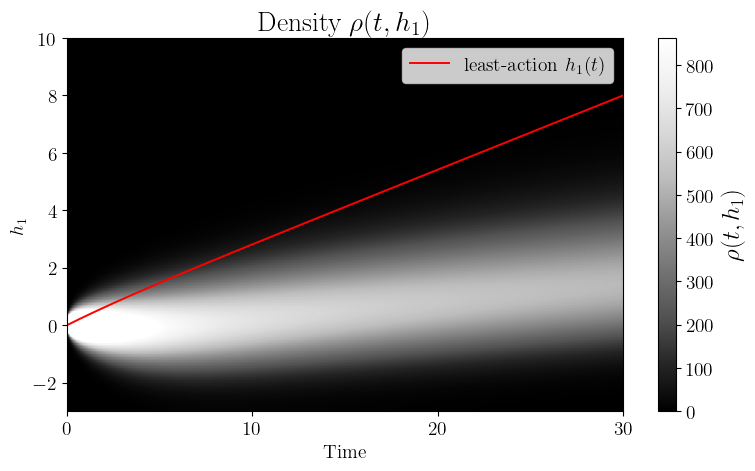

S_opt = 5.952495e+00   S_lin = 5.969967e+00   ΔS = 1.747164e-02


In [ ]:
def get_C(t, v):
    return 300.  # Use the mean of the optimized concentrations

# ------------------------------------------------------------------
# 3. Run the FP simulation with the optimized concentrations
# ------------------------------------------------------------------
fp_ctx_final = run_fp(S_mat, get_C, T=T, verbose=True)

fp_ctx_safe = copy.deepcopy(fp_ctx_final)
sol = solve_optimal_trajectory([8], fp_ctx_safe)
print(f"Optimal trajectory: {sol.x.shape} with shape {sol.y.shape}")
plot_fp_density_time_dim(fp_ctx_final, sol=sol, disp_step=10, cmap="Greys_r")
S,_=compute_least_action(sol, fp_ctx_final, verbose=True)
results['300']=fp_ctx_safe

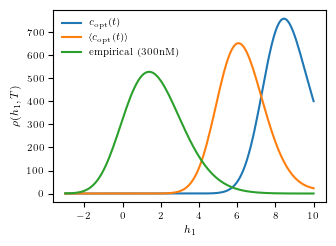

In [ ]:
import matplotlib.pyplot as plt

# Set PRL-compatible figure size and fonts
plt.figure(figsize=(3.4, 2.5))
plt.rcParams.update({
    "font.size": 8,
    "axes.labelsize": 8,
    "axes.titlesize": 8,
    "legend.fontsize": 7,
    "xtick.labelsize": 7,
    "ytick.labelsize": 7,
    "text.usetex": True,
    "font.family": "serif"
})

# Define label mapping
label_map = {
    "copt": r"$c_{\mathrm{opt}}(t)$",
    "mean": r"$\langle c_{\mathrm{opt}}(t) \rangle$",
    "300": r"empirical (300\,nM)"
}

# Plot
for key in ['copt', 'mean', '300']:
    if key not in results:
        print(key)
        continue
    res = results[key]
    plt.plot(res["axes"][0], res["rho_t"][-1], label=label_map[key], lw=1.5)

# Axis labels and formatting
plt.xlabel(r"$h_1$")
plt.ylabel(r"$\rho(h_1, T)$")
plt.legend(frameon=False, loc="upper left")
plt.tight_layout()
plt.show()
